# **Phase D — Country Life Expectancy Advisory**

### *"A country comes to you asking how to improve their Life Expectancy"*

| Section | Output |
|---------|--------|
| 1 | **Country status** — global rank, continent position, KPI cards |
| 2 | **Peer group** — cluster assignment and similar countries |
| 3 | **Comparison tables** — 10 model features vs peers, outperformers, global |
| 4 | **SHAP priority matrix** — model-validated levers ranked by impact × gap |
| 5 | **What to improve** — prioritised gaps with targets |
| 6a | **What to protect** — existing strengths above peer average |
| 6b | **Mortality burden** — top killers, excess causes vs peers, trend |
| 6c | **Vaccination gaps** — all vaccines vs WHO 95% target and peer coverage |
| 6d | **Poverty & inequality lens** — full poverty staircase + Gini + income distribution |
| 7 | **Historical trend** — LE and indicator trajectories |
| 8a | **Scenario simulation** — LE under 25/50/75% gap closure |
| 8b | **Timeline & cost advisory** — how long, what year, what it costs |
| 9 | **Benchmark countries** — who solved this problem and how |
| 10 | **Advisory export** — summary CSV + full feature comparison |

**Unknown country?** Set `COUNTRY_GDP_PER_CAPITA` and `COUNTRY_CONTINENT` in the config cell — the notebook will profile it via nearest-neighbour imputation.

**Why are 6b/6c/6d separate from the model features?** The 10 Phase B/C model features were selected for *predictive accuracy*. Cause-of-death, vaccination, and poverty columns were deliberately excluded to avoid multicollinearity. Sections 6b–6d query them directly from the raw dataset — this gives a richer clinical picture without compromising the model.

## **~Libraries~**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
from os.path import join

import json as _json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler

import joblib

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

---
## ⚙️ Configuration — set your country here

In [2]:
# ============================================================================
# ⚙️  SET THE COUNTRY TO ADVISE HERE
# ============================================================================

COUNTRY = 'Kosovo'        # <-- Change this to any country in the dataset
                            #     If the country is NOT in the dataset, set
                            #     COUNTRY_GDP and COUNTRY_CONTINENT below and
                            #     the notebook will profile it via nearest-neighbour.

# ── For countries NOT in the dataset ─────────────────────────────────────────
# If COUNTRY is not found automatically, the notebook will ask for these values.
# You can pre-fill them here to skip the interactive prompt.
COUNTRY_GDP_PER_CAPITA = 7900    # e.g. 8500  (USD, leave None to auto-detect)
COUNTRY_CONTINENT      = 'Asia'    # e.g. 'South America' (leave None to auto-detect)
COUNTRY_KNOWN_LE       = None    # e.g. 74.5  (if you know it; None = will be estimated)

# ── Time horizon for forecasting (Section 8b) ────────────────────────────────
FORECAST_YEARS = [2027, 2030, 2035, 2040, 2045]  # years to project LE improvement

# ── Scenario gap closure fractions (Section 8a) ──────────────────────────────
SCENARIOS = {
    '25% gap closure': 0.25,
    '50% gap closure': 0.50,
    '75% gap closure': 0.75,
}

# Years to use for the country's current profile (recent average)
PROFILE_YEARS  = range(2018, 2024)
TREND_YEARS    = range(2000, 2024)

TARGET  = 'Life Expectancy'
ID_COLS = ['Country', 'Continent', 'Year']

CONTINENT_COLORS = {
    'Africa':        '#66c2a5',
    'Asia':          '#fc8d62',
    'Europe':        '#8da0cb',
    'North America': '#e78ac3',
    'Oceania':       '#a6d854',
    'South America': '#ffd92f',
}

print(f'📍 Country under analysis: {COUNTRY}')

# ============================================================================

📍 Country under analysis: Kosovo


---
# **0. Load All Pipeline Outputs**

In [3]:
# ── 0a. Raw panel + cluster assignments — with unknown-country fallback ───────

df_panel    = pd.read_csv('Phase_A_docs/df_merged_all_imputed.csv')
df_clusters = pd.read_csv('Phase_B_docs/df_clustered_countries.csv')

print(f'Panel: {df_panel.shape}  |  Clustered countries: {df_clusters.shape[0]}')

all_countries = df_panel['Country'].unique()
COUNTRY_IN_DATASET = COUNTRY in all_countries
IS_PROXY = False   # will be set True if we use nearest-neighbour imputation

if COUNTRY_IN_DATASET:
    print(f'✅  "{COUNTRY}" found in dataset — running full advisory.')

else:
    # ── Fuzzy match first: maybe it's just a spelling difference ────────────
    fuzzy = [c for c in all_countries if COUNTRY.lower() in c.lower() or
             c.lower() in COUNTRY.lower()]
    if fuzzy:
        print(f'⚠️  "{COUNTRY}" not found exactly.')
        print(f'   Did you mean one of these? {fuzzy}')
        print(f'   If yes, update COUNTRY in the config cell.')
        print(f'   Continuing with nearest-neighbour proxy for "{COUNTRY}"...')
    else:
        print(f'ℹ️  "{COUNTRY}" is not in the training dataset.')
        print(f'   We will estimate its profile using nearest-neighbour matching')
        print(f'   against the {len(all_countries)} countries we do have data for.')

    # ── Collect anchor values ────────────────────────────────────────────────
    # Use pre-filled config values; fall back to user input if None.
    gdp_val  = COUNTRY_GDP_PER_CAPITA
    cont_val = COUNTRY_CONTINENT
    le_val   = COUNTRY_KNOWN_LE

    if gdp_val is None:
        try:
            gdp_val = float(input(f'  Enter GDP per capita (USD) for {COUNTRY}: '))
        except Exception:
            gdp_val = df_panel['GDP per Capita'].median()
            print(f'  Using global median GDP: {gdp_val:.0f}')

    if cont_val is None:
        try:
            cont_val = input(f'  Enter continent for {COUNTRY} '
                             f'(Africa/Asia/Europe/North America/Oceania/South America): ').strip()
        except Exception:
            cont_val = 'Asia'
            print(f'  Using default continent: {cont_val}')

    # ── Nearest-neighbour matching ───────────────────────────────────────────
    # Match on GDP per capita (primary) + continent (secondary bonus)
    # Strategy: compute |log(GDP_country) - log(GDP_i)| for all i,
    #           subtract 0.2 bonus if same continent.
    df_profile_all = (
        df_panel[df_panel['Year'].isin(PROFILE_YEARS)]
        .groupby(['Country', 'Continent'])
        .mean(numeric_only=True)
        .reset_index()
    )

    if 'GDP per Capita' in df_profile_all.columns:
        gdp_col = 'GDP per Capita'
    else:
        gdp_col = [c for c in df_profile_all.columns if 'gdp' in c.lower() or 'GDP' in c][0]

    df_profile_all = df_profile_all.dropna(subset=[gdp_col])
    df_profile_all['_log_gdp'] = np.log(df_profile_all[gdp_col].clip(lower=1))
    log_gdp_target = np.log(max(gdp_val, 1))

    df_profile_all['_dist'] = (df_profile_all['_log_gdp'] - log_gdp_target).abs()
    # Continent bonus
    df_profile_all['_dist'] -= 0.20 * (df_profile_all['Continent'] == cont_val).astype(float)
    df_profile_all = df_profile_all.sort_values('_dist')

    # Top-5 nearest neighbours
    nn5 = df_profile_all.head(5)
    print(f'\n🔍 Nearest neighbours for "{COUNTRY}" (GDP=${gdp_val:,.0f}, {cont_val}):')
    for _, r in nn5.iterrows():
        print(f'   {r["Country"]:25s}  GDP={r[gdp_col]:8,.0f}  LE={r["Life Expectancy"]:.1f}  ({r["Continent"]})')

    # Build synthetic profile = weighted average of top-5 (inverse-distance weights)
    weights = 1 / (df_profile_all.head(5)['_dist'].values + 1e-6)
    weights = weights / weights.sum()

    num_cols = [c for c in df_profile_all.columns
                if c not in ['Country', 'Continent', '_log_gdp', '_dist']
                and df_profile_all[c].dtype in ['float64', 'int64']]

    synthetic_profile = pd.Series(
        (nn5[num_cols].values * weights[:, None]).sum(axis=0),
        index=num_cols
    )
    synthetic_profile['GDP per Capita'] = gdp_val

    # Override LE if user provided it
    if le_val is not None:
        synthetic_profile['Life Expectancy'] = le_val

    # Build a synthetic country row in df_panel so all downstream code works
    synthetic_rows = []
    for yr in list(PROFILE_YEARS) + list(TREND_YEARS):
        row = {'Country': COUNTRY, 'Continent': cont_val, 'Year': yr}
        row.update(synthetic_profile.to_dict())
        synthetic_rows.append(row)

    df_synthetic = pd.DataFrame(synthetic_rows)
    df_panel     = pd.concat([df_panel, df_synthetic], ignore_index=True)

    # Build synthetic cluster assignment (closest outperformer from nearest cluster)
    closest_country   = nn5.iloc[0]['Country']
    closest_cluster_r = df_clusters[df_clusters['Country'] == closest_country]

    if len(closest_cluster_r) > 0:
        synth_cluster = closest_cluster_r.iloc[0].to_dict()
        synth_cluster['Country']    = COUNTRY
        synth_cluster['Continent']  = cont_val
        synth_cluster['Life Expectancy'] = synthetic_profile['Life Expectancy']
        # Recompute LE residual vs cluster mean
        cid   = synth_cluster['Cluster']
        c_mean = df_clusters[df_clusters['Cluster'] == cid]['Life Expectancy'].mean()
        synth_cluster['LE_Residual'] = synthetic_profile['Life Expectancy'] - c_mean
        synth_cluster['Performance'] = (
            'Outperformer' if synth_cluster['LE_Residual'] > 0.5
            else 'Underperformer' if synth_cluster['LE_Residual'] < -0.5
            else 'Average'
        )
        df_clusters = pd.concat(
            [df_clusters, pd.DataFrame([synth_cluster])], ignore_index=True
        )

    IS_PROXY = True
    print(f'\n✅  Synthetic profile created for "{COUNTRY}" via nearest-neighbour imputation.')
    print(f'   Estimated LE: {synthetic_profile["Life Expectancy"]:.1f} years')
    print(f'   Assigned to cluster of: {closest_country}')
    print()
    print('   ⚠️  All estimates for this country are MODELLED, not observed.')
    print('      Treat results as indicative — not ground truth.')

print(f'\nDataset ready: {df_panel["Country"].nunique()} countries  |  IS_PROXY={IS_PROXY}')

Panel: (3096, 67)  |  Clustered countries: 128
ℹ️  "Kosovo" is not in the training dataset.
   We will estimate its profile using nearest-neighbour matching
   against the 129 countries we do have data for.

🔍 Nearest neighbours for "Kosovo" (GDP=$7,900, Asia):
   Lebanon                    GDP=   7,842  LE=77.0  (Asia)
   Iraq                       GDP=   7,531  LE=71.2  (Asia)
   Iran                       GDP=   7,335  LE=76.0  (Asia)
   Armenia                    GDP=   8,668  LE=73.7  (Asia)
   Mongolia                   GDP=   7,004  LE=70.5  (Asia)

✅  Synthetic profile created for "Kosovo" via nearest-neighbour imputation.
   Estimated LE: 73.2 years
   Assigned to cluster of: Lebanon

   ⚠️  All estimates for this country are MODELLED, not observed.
      Treat results as indicative — not ground truth.

Dataset ready: 130 countries  |  IS_PROXY=True


In [4]:
global_mean = df_clusters[TARGET].mean()
global_std  = df_clusters[TARGET].std()

df_clusters['Performance_Global'] = df_clusters[TARGET].apply(
    lambda le: 'Above Global Average' if le > global_mean
               else ('Below Global Average' if le < global_mean else 'At Global Average')
)

In [5]:
# ── 0b. Phase C model + metadata ──────────────────────────────────────────────

try:
    best_model = joblib.load('Phase_C_docs/best_model.joblib')
    scaler     = joblib.load('Phase_C_docs/feature_scaler.joblib')
    with open('Phase_C_docs/model_metadata.json') as f:
        model_meta = _json.load(f)
    feature_cols = model_meta['feature_cols']
    lag_applied  = model_meta['lag_applied']
    MODEL_AVAILABLE = True
    print(f'✅ Model loaded: {model_meta["model_name"]}  '
          f'(Test R²={model_meta["test_r2"]:.3f})')
    print(f'   Features: {feature_cols}')
except FileNotFoundError:
    MODEL_AVAILABLE = False
    feature_cols = []
    lag_applied  = {}
    print('⚠️  Phase C model not found — Section 8 (scenario simulation) will be skipped.')
    print('   Run phase_c_modeling.ipynb first to enable predictions.')

# ── 0c. SHAP feature ranking ──────────────────────────────────────────────────

try:
    df_shap_rank = pd.read_csv('Phase_C_docs/shap_feature_ranking.csv')
    SHAP_RANK_AVAILABLE = True
    print(f'\n✅ SHAP ranking loaded: {len(df_shap_rank)} features')
except FileNotFoundError:
    df_shap_rank = None
    SHAP_RANK_AVAILABLE = False
    print('⚠️  shap_feature_ranking.csv not found — importance ranking will use cluster features only.')

✅ Model loaded: XGBoost (Optuna)  (Test R²=0.929)
   Features: ['Child mortality rate', 'Tuberculosis', 'Maternal disorders', 'Median income or consumption per day', "Alzheimer's disease and other dementias", "Parkinson's disease", 'Share below $3.65 a day', 'Share below $2.15 a day', 'GDP per Capita_lag1', 'Lower respiratory infections', 'Homicide Rate', 'HIV/AIDS']

✅ SHAP ranking loaded: 12 features


In [6]:
# ── 0d. Build country profile (recent average) ────────────────────────────────

id_cols  = ['Country', 'Year', 'Continent']
num_cols = [c for c in df_panel.columns if c not in id_cols
            and df_panel[c].dtype in ['float64', 'int64', 'Float64', 'Int64']]

if IS_PROXY:
    # Use the synthetic profile built in cell 6 directly — avoids dtype issues
    # from pd.concat introducing object columns
    country_profile   = synthetic_profile
    country_continent = cont_val
    latest_le_val     = float(synthetic_profile['Life Expectancy'])
    latest_year       = int(max(PROFILE_YEARS))
else:
    df_recent = df_panel[df_panel['Year'].isin(PROFILE_YEARS)].copy()
    country_profile = (
        df_recent[df_recent['Country'] == COUNTRY]
        .groupby('Country')[num_cols].mean()
        .iloc[0]
    )
    country_continent = df_panel[df_panel['Country'] == COUNTRY]['Continent'].dropna().iloc[0]
    latest_le = (
        df_panel[df_panel['Country'] == COUNTRY]
        .sort_values('Year')
        .dropna(subset=[TARGET])
        .iloc[-1]
    )
    latest_year   = int(latest_le['Year'])
    latest_le_val = latest_le[TARGET]

# Cluster assignment — same for both proxy and real countries
country_cluster_row = df_clusters[df_clusters['Country'] == COUNTRY]
if len(country_cluster_row) == 0:
    print(f'⚠️  {COUNTRY} not found in df_clustered_countries.csv')
    print('   Re-run phase_b_clustering.ipynb with candidates_shap.json first.')
    CLUSTER_AVAILABLE = False
    cluster_id, cluster_label, performance, le_residual = None, 'Unknown', 'Unknown', 0.0
else:
    CLUSTER_AVAILABLE = True
    country_cluster_row = country_cluster_row.iloc[0]
    cluster_id    = country_cluster_row['Cluster']
    cluster_label = country_cluster_row['Cluster_Label']
    performance   = country_cluster_row['Performance']
    le_residual   = country_cluster_row['LE_Residual']

print(f'\n{"="*60}')
print(f'  COUNTRY PROFILE: {COUNTRY.upper()}')
print(f'  Continent      : {country_continent}')
print(f'  Life Expectancy: {latest_le_val:.1f} years ({latest_year})')
print(f'  Cluster        : {cluster_label}')
print(f'  Performance    : {performance}  (residual: {le_residual:+.1f} yrs vs cluster mean)')
print(f'={"="*60}')


  COUNTRY PROFILE: KOSOVO
  Continent      : Asia
  Life Expectancy: 73.2 years (2023)
  Cluster        : Middle-Income Transition
  Performance    : Average  (residual: -0.0 yrs vs cluster mean)


---
# **1. Country Status — Where They Stand Today**

In [7]:
# ── 1a. Global rank and context ───────────────────────────────────────────────

# Build global and regional snapshots
df_snap = (
    df_panel[df_panel['Year'] == latest_year]
    .dropna(subset=[TARGET])
    .copy()
)

global_le      = df_snap[TARGET].mean()
global_le_med  = df_snap[TARGET].median()
global_rank    = int((df_snap[TARGET] > latest_le_val).sum()) + 1
global_n       = len(df_snap)
percentile     = round((1 - global_rank / global_n) * 100, 1)

region_snap    = df_snap[df_snap['Continent'] == country_continent]
region_le      = region_snap[TARGET].mean()
region_rank    = int((region_snap[TARGET] > latest_le_val).sum()) + 1
region_n       = len(region_snap)

top10_le  = df_snap[TARGET].quantile(0.90)
gap_top10 = top10_le - latest_le_val
gap_global_mean = latest_le_val - global_le

print(f'\n📊 LIFE EXPECTANCY STATUS — {COUNTRY} ({latest_year})')
print(f'{'='*60}')
print(f'  {COUNTRY:<30} {latest_le_val:.1f} years')
print(f'  Global average               {global_le:.1f} years')
print(f'  {country_continent} average             {region_le:.1f} years')
print(f'  Global top 10% threshold     {top10_le:.1f} years')
print(f'{'='*60}')
print(f'  Global rank  : {global_rank}/{global_n}  (top {percentile}%)')
print(f'  {country_continent} rank   : {region_rank}/{region_n}')
print(f'  vs global avg: {gap_global_mean:+.1f} years')
print(f'  Gap to top 10%: {gap_top10:.1f} years')


📊 LIFE EXPECTANCY STATUS — Kosovo (2023)
  Kosovo                         73.2 years
  Global average               74.6 years
  Asia average             75.3 years
  Global top 10% threshold     82.5 years
  Global rank  : 79/129  (top 38.8%)
  Asia rank   : 21/33
  vs global avg: -1.4 years
  Gap to top 10%: 9.3 years


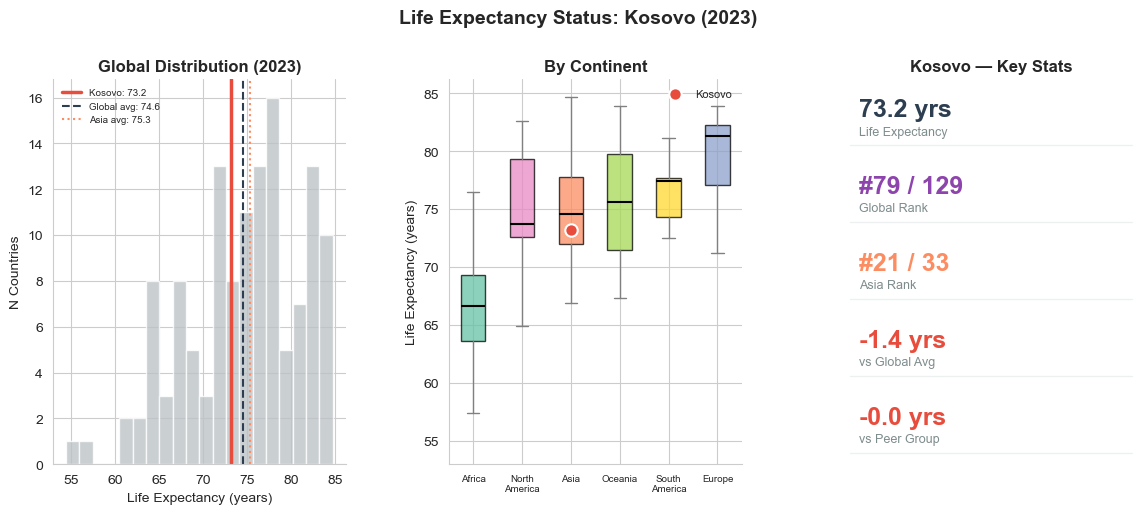

In [8]:
# ── 1b. Status dashboard ──────────────────────────────────────────────────────

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Panel A — LE distribution with country marker
ax1 = fig.add_subplot(gs[0, 0])
le_vals = df_snap[TARGET].dropna()
ax1.hist(le_vals, bins=20, color='#bdc3c7', edgecolor='white', alpha=0.8)
ax1.axvline(latest_le_val, color='#e74c3c', linewidth=2.5, label=f'{COUNTRY}: {latest_le_val:.1f}')
ax1.axvline(global_le,     color='#2c3e50', linewidth=1.5, linestyle='--', label=f'Global avg: {global_le:.1f}')
ax1.axvline(region_le,     color=CONTINENT_COLORS.get(country_continent, 'grey'),
            linewidth=1.5, linestyle=':', label=f'{country_continent} avg: {region_le:.1f}')
ax1.set_xlabel('Life Expectancy (years)')
ax1.set_ylabel('N Countries')
ax1.set_title(f'Global Distribution ({latest_year})', fontweight='bold')
ax1.legend(fontsize=7, frameon=False)
ax1.spines[['top', 'right']].set_visible(False)

# Panel B — Continent comparison box
ax2 = fig.add_subplot(gs[0, 1])
cont_order = df_snap.groupby('Continent')[TARGET].median().sort_values().index.tolist()
cont_data  = [df_snap[df_snap['Continent'] == c][TARGET].dropna().values for c in cont_order]
bp = ax2.boxplot(cont_data, vert=True, patch_artist=True, widths=0.5,
                 medianprops=dict(color='black', linewidth=1.5),
                 whiskerprops=dict(color='grey'),
                 capprops=dict(color='grey'),
                 flierprops=dict(marker='', markersize=0))
for patch, cont in zip(bp['boxes'], cont_order):
    patch.set_facecolor(CONTINENT_COLORS.get(cont, '#bdc3c7'))
    patch.set_alpha(0.75)
# Mark country on its continent
cont_idx = cont_order.index(country_continent) + 1
ax2.scatter([cont_idx], [latest_le_val], color='#e74c3c', s=80, zorder=5,
            edgecolor='white', linewidth=1.5, label=COUNTRY)
ax2.set_xticks(range(1, len(cont_order) + 1))
ax2.set_xticklabels([c.replace(' ', '\n') for c in cont_order], fontsize=7)
ax2.set_ylabel('Life Expectancy (years)')
ax2.set_title('By Continent', fontweight='bold')
ax2.legend(fontsize=8, frameon=False)
ax2.spines[['top', 'right']].set_visible(False)

# Panel C — KPI cards
ax3 = fig.add_subplot(gs[0, 2])
ax3.axis('off')
kpis = [
    (f'{latest_le_val:.1f} yrs', 'Life Expectancy', '#2c3e50'),
    (f'#{global_rank} / {global_n}', 'Global Rank', '#8e44ad'),
    (f'#{region_rank} / {region_n}', f'{country_continent} Rank', CONTINENT_COLORS.get(country_continent, '#3498db')),
    (f'{gap_global_mean:+.1f} yrs', 'vs Global Avg',
     '#2ecc71' if gap_global_mean >= 0 else '#e74c3c'),
    (f'{le_residual:+.1f} yrs', 'vs Peer Group',
     '#2ecc71' if le_residual >= 0 else '#e74c3c'),
]
for i, (val, label, color) in enumerate(kpis):
    y = 0.95 - i * 0.20
    ax3.text(0.05, y, val, fontsize=18, fontweight='bold', color=color, transform=ax3.transAxes, va='top')
    ax3.text(0.05, y - 0.07, label, fontsize=9, color='#7f8c8d', transform=ax3.transAxes, va='top')
    # Draw divider line using ax3.plot() with axes transform — avoids axhline's transform restriction
    y_line = 1 - (i + 1) * 0.20 + 0.03
    ax3.plot([0.02, 0.98], [y_line, y_line], color='#ecf0f1', linewidth=1,
             transform=ax3.transAxes, clip_on=False)
ax3.set_title(f'{COUNTRY} — Key Stats', fontweight='bold')

plt.suptitle(f'Life Expectancy Status: {COUNTRY} ({latest_year})',
             fontsize=14, fontweight='bold', y=1.02)
#plt.savefig(f'advisory_{COUNTRY.lower().replace(" ","_")}_status.png', dpi=150, bbox_inches='tight')
plt.show()
#print(f'✅ Saved: advisory_{COUNTRY.lower().replace(" ","_")}_status.png')

---
# **2. Peer Group — Cluster Assignment**

In [9]:
# ── 2a. Identify peers ────────────────────────────────────────────────────────

if not CLUSTER_AVAILABLE:
    print('Cluster data not available — run phase_b_clustering.ipynb first.')
else:
    df_peers = df_clusters[df_clusters['Cluster'] == cluster_id].copy()

    # Get feature columns from cluster file
    cluster_feature_cols = [
        c for c in df_clusters.columns
        if c not in ['Country', 'Continent', 'Cluster', 'Cluster_Label',
                     'Performance', 'Performance_Global', 'LE_Residual', TARGET]
    ]

    outperformers  = df_peers[df_peers['Performance'] == 'Outperformer'].sort_values('LE_Residual', ascending=False)
    underperformers= df_peers[df_peers['Performance'] == 'Underperformer'].sort_values('LE_Residual')
    average_peers  = df_peers[df_peers['Performance'] == 'Average']

    print(f'\n🌍 PEER GROUP: {cluster_label}')
    print(f'{'='*70}')
    print(f'  Total peers    : {len(df_peers)}')
    print(f'  Outperformers  : {len(outperformers)}')
    print(f'  Average        : {len(average_peers)}')
    print(f'  Underperformers: {len(underperformers)}')
    print(f'  Cluster avg LE : {df_peers[TARGET].mean():.1f} years')
    print(f'  {COUNTRY} LE   : {latest_le_val:.1f} years  (residual: {le_residual:+.1f})')
    print(f'\n  Outperformers: {", ".join(outperformers["Country"].tolist())}')
    print(f'  Underperformers: {", ".join(underperformers["Country"].tolist())}')
    print(f'\n  All peers:')
    display(
        df_peers[['Country', 'Continent', TARGET, 'LE_Residual', 'Performance']]
        .sort_values(TARGET, ascending=False)
        .reset_index(drop=True)
    )


🌍 PEER GROUP: Middle-Income Transition
  Total peers    : 52
  Outperformers  : 18
  Average        : 18
  Underperformers: 16
  Cluster avg LE : 73.2 years
  Kosovo LE   : 73.2 years  (residual: -0.0)

  Outperformers: Chile, Costa Rica, Maldives, Panama, China, Lebanon, Türkiye, Thailand, Sri Lanka, Jordan, Iran, Colombia, Ecuador, Peru, Malaysia, Algeria, Tunisia, Brazil
  Underperformers: Botswana, Bolivia, Fiji, Sao Tome and Principe, Nepal, Syria, Philippines, Indonesia, India, Mongolia, Tajikistan, Egypt, Iraq, Guatemala, El Salvador, Jamaica

  All peers:


,Country,Continent,Life Expectancy,LE_Residual,Performance
0,Chile,South America,80.040467,6.850000,Outperformer
1,Costa Rica,North America,79.851811,6.660000,Outperformer
2,Maldives,Asia,79.383756,6.200000,Outperformer
3,Panama,North America,78.032000,4.840000,Outperformer
4,China,Asia,77.707122,4.520000,Outperformer
5,Lebanon,Asia,77.445911,4.260000,Outperformer
6,Türkiye,Asia,76.928456,3.740000,Outperformer
7,Thailand,Asia,76.816544,3.630000,Outperformer
8,Sri Lanka,Asia,76.615144,3.430000,Outperformer
9,Jordan,Asia,76.080722,2.890000,Outperformer


In [10]:
# ── 2b. Peer group LE scatter ─────────────────────────────────────────────────

if CLUSTER_AVAILABLE:
    fig = px.strip(
        df_peers.sort_values(TARGET, ascending=False),
        x='Performance', y=TARGET,
        color='Performance',
        color_discrete_map={
            'Outperformer': '#2ecc71', 'Average': '#95a5a6', 'Underperformer': '#e74c3c'
        },
        hover_name='Country',
        hover_data=['Continent', 'LE_Residual'],
        title=f'Peer Group: {cluster_label}<br>'
              f'<sub>{COUNTRY} highlighted in black</sub>',
        stripmode='overlay'
    )
    # Highlight focal country
    focal = df_peers[df_peers['Country'] == COUNTRY]
    if len(focal) > 0:
        fig.add_trace(go.Scatter(
            x=[focal['Performance'].iloc[0]],
            y=[focal[TARGET].iloc[0]],
            mode='markers',
            marker=dict(size=18, color='black', symbol='diamond',
                        line=dict(width=2, color='white')),
            name=COUNTRY, showlegend=True
        ))
    # Cluster mean line
    fig.add_hline(y=df_peers[TARGET].mean(), line_dash='dash', line_color='grey',
                  annotation_text=f'Cluster avg: {df_peers[TARGET].mean():.1f}',
                  annotation_position='bottom right')
    fig.update_layout(height=500, template='plotly_white',
                      xaxis_title='Performance Category',
                      yaxis_title='Life Expectancy (years)')
    fig.update_traces(marker_size=10, selector=dict(type='scatter'))
    fig.show()

---
# **3. Comparison Tables — Feature-by-Feature**

In [11]:
# ── 3a. Build comparison reference points ─────────────────────────────────────
#
# For each feature we compare COUNTRY against:
#   - Peer cluster average
#   - Outperformer average (benchmark target)
#   - Global average
#   - Global top-25% threshold

if not CLUSTER_AVAILABLE:
    print('Cluster data required — run phase_b_clustering.ipynb first.')
else:
    LOWER_IS_BETTER = [
        'Child Mortality Rate', 'Child mortality rate',
        'Suicide Rate', 'Homicide Rate', 'Homicide',
        'gini', 'palma_ratio', 'p90_p10_ratio',
        'HIV/AIDS', 'Malaria', 'Tuberculosis',
        'Cardiovascular diseases', 'Neoplasms',
        'Chronic respiratory diseases', 'Maternal disorders',
        'Neonatal disorders', 'Share below $6.85 a day',
        'Share below $2.15 a day', 'Share below $3.65 a day',
    ]

    # Build global profile (recent years)
    df_global_recent = df_panel[df_panel['Year'].isin(PROFILE_YEARS)]
    global_profile   = df_global_recent.groupby('Country').mean(numeric_only=True).mean()
    global_top25     = df_global_recent.groupby('Country').mean(numeric_only=True).quantile(0.75)
    global_bot25     = df_global_recent.groupby('Country').mean(numeric_only=True).quantile(0.25)

    peer_profile      = df_peers[cluster_feature_cols].mean() if len(df_peers) > 0 else pd.Series(dtype=float)
    outperf_profile   = outperformers[cluster_feature_cols].mean() if len(outperformers) > 0 else pd.Series(dtype=float)

    comparison_rows = []
    for feat in cluster_feature_cols:
        if feat not in country_profile.index:
            continue

        country_val   = country_profile.get(feat, np.nan)
        peer_val      = peer_profile.get(feat, np.nan)
        outperf_val   = outperf_profile.get(feat, np.nan)
        global_val    = global_profile.get(feat, np.nan)

        if np.isnan(country_val):
            continue

        # Z-score vs peers
        peer_std = df_peers[feat].std() if feat in df_peers.columns else np.nan
        z_peer   = (country_val - peer_val) / peer_std if peer_std and peer_std > 0 else np.nan

        # Gap to outperformer (positive = country is worse)
        lib = any(kw.lower() in feat.lower() for kw in LOWER_IS_BETTER)
        if lib:
            gap_to_outperf = country_val - outperf_val   # positive = country has more (worse)
            better_than_peer = country_val < peer_val
        else:
            gap_to_outperf = outperf_val - country_val   # positive = country has less (worse)
            better_than_peer = country_val > peer_val

        status = '✅ Strength' if better_than_peer else '⚠️ Gap'

        comparison_rows.append({
            'Feature'          : feat,
            'Lower is Better'  : lib,
            COUNTRY            : round(country_val, 2),
            'Peer Average'     : round(peer_val, 2) if not np.isnan(peer_val) else np.nan,
            'Outperformer Avg' : round(outperf_val, 2) if not np.isnan(outperf_val) else np.nan,
            'Global Average'   : round(global_val, 2) if not np.isnan(global_val) else np.nan,
            'Z vs Peers'       : round(z_peer, 2) if not np.isnan(z_peer) else np.nan,
            'Gap to Outperformer': round(gap_to_outperf, 2) if not np.isnan(gap_to_outperf) else np.nan,
            'Status'           : status,
        })

    df_comparison = pd.DataFrame(comparison_rows)
    df_comparison['Abs Gap'] = df_comparison['Gap to Outperformer'].abs()

    print(f'\nFeature comparison table — {COUNTRY} vs peer group ({cluster_label}):')
    display(
        df_comparison[[
            'Feature', 'Status', COUNTRY,
            'Peer Average', 'Outperformer Avg', 'Global Average',
            'Z vs Peers', 'Gap to Outperformer'
        ]]
        .sort_values('Gap to Outperformer', ascending=False)
        .reset_index(drop=True)
    )


Feature comparison table — Kosovo vs peer group (Middle-Income Transition):


,Feature,Status,Kosovo,Peer Average,Outperformer Avg,Global Average,Z vs Peers,Gap to Outperformer
0,Cardiovascular diseases,⚠️ Gap,253.40,196.94,172.56,270.40,0.84,80.84
1,Neoplasms,⚠️ Gap,129.99,96.67,105.86,153.42,0.97,24.13
2,DTP3,✅ Strength,90.31,88.65,91.00,87.87,0.16,0.69
3,Malaria,✅ Strength,0.00,0.10,0.02,8.63,-0.34,-0.02
4,gini,✅ Strength,0.33,0.39,0.40,0.37,-0.89,-0.07
5,HIV/AIDS,✅ Strength,0.54,1.46,1.31,21.31,-0.93,-0.77
6,GDP per Capita,✅ Strength,7900.00,9.02,9.40,18404.64,13345.77,-7890.60


In [12]:
# ── 3b. Radar chart — country vs peers vs outperformers ───────────────────────

if CLUSTER_AVAILABLE and len(comparison_rows) > 0:
    # Normalise to 0–1 for radar (direction-corrected: 1 = better)
    radar_feats = df_comparison['Feature'].tolist()
    scaler_mm   = MinMaxScaler()

    # Build matrix: rows = [country, peer_avg, outperf_avg]
    raw_vals = df_comparison[[COUNTRY, 'Peer Average', 'Outperformer Avg']].values.T

    # Normalise column-wise (feature-wise)
    norm_vals = np.zeros_like(raw_vals, dtype=float)
    for j, feat in enumerate(radar_feats):
        col = raw_vals[:, j]
        col_clean = col[~np.isnan(col)]
        if len(col_clean) < 2 or col_clean.max() == col_clean.min():
            norm_vals[:, j] = 0.5
            continue
        norm = (col - col_clean.min()) / (col_clean.max() - col_clean.min())
        # Flip direction for lower-is-better
        lib = df_comparison.loc[df_comparison['Feature'] == feat, 'Lower is Better'].iloc[0]
        norm_vals[:, j] = 1 - norm if lib else norm

    # Close the polygon
    theta  = radar_feats + [radar_feats[0]]
    fig    = go.Figure()
    labels = [COUNTRY, 'Peer Average', 'Outperformer Avg']
    colors = ['#e74c3c', '#95a5a6', '#2ecc71']
    dashes = ['solid', 'dash', 'solid']

    for i, (label, color, dash) in enumerate(zip(labels, colors, dashes)):
        vals = list(norm_vals[i]) + [norm_vals[i][0]]
        fig.add_trace(go.Scatterpolar(
            r=vals, theta=theta,
            fill='toself' if label == COUNTRY else 'none',
            name=label,
            line=dict(color=color, width=2.5 if label == COUNTRY else 2, dash=dash),
            opacity=0.7 if label == COUNTRY else 0.9
        ))

    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 1],
                                   ticktext=['Worst', '', 'Mid', '', 'Best'],
                                   tickvals=[0, 0.25, 0.5, 0.75, 1.0])),
        title=f'Performance Radar: {COUNTRY} vs Peers vs Outperformers<br>'
              '<sub>1 = best possible direction for each indicator (lower-is-better features are flipped)</sub>',
        width=700, height=600, font=dict(size=11)
    )
    fig.show()

---
# **4. SHAP-Powered Priority Matrix**

We combine two dimensions to rank improvement priorities:
- **Model impact** — SHAP importance: how much does this feature move LE predictions globally?
- **Country gap** — how far is the country from its outperformer benchmark?

Features that are **high impact AND have a large gap** are the highest priority.

In [13]:
# ── 4a. Build priority matrix ─────────────────────────────────────────────────

if CLUSTER_AVAILABLE and len(comparison_rows) > 0:

    df_priority = df_comparison[['Feature', 'Status', 'Gap to Outperformer', 'Abs Gap', 'Lower is Better']].copy()

    # Join SHAP importance if available
    if SHAP_RANK_AVAILABLE:
        shap_map = df_shap_rank.set_index('Feature')['Mean_Abs_SHAP'].to_dict()
        df_priority['SHAP Importance'] = df_priority['Feature'].map(shap_map)
        # Normalise importance to 0–1
        max_shap = df_priority['SHAP Importance'].max()
        df_priority['SHAP_norm'] = df_priority['SHAP Importance'] / max_shap if max_shap > 0 else 0.5
    else:
        # Fallback: equal weight
        df_priority['SHAP Importance'] = 1.0
        df_priority['SHAP_norm'] = 1.0

    # Normalise gap to 0–1
    max_gap = df_priority['Abs Gap'].max()
    df_priority['Gap_norm'] = df_priority['Abs Gap'] / max_gap if max_gap > 0 else 0.0

    # Priority score = geometric mean of impact and gap (only for gaps, not strengths)
    df_priority['Priority Score'] = np.where(
        df_priority['Status'] == '⚠️ Gap',
        np.sqrt(df_priority['SHAP_norm'] * df_priority['Gap_norm']),
        0.0
    )

    df_priority = df_priority.sort_values('Priority Score', ascending=False).reset_index(drop=True)
    df_priority['Priority Rank'] = df_priority.index + 1

    print(f'SHAP-Powered Priority Matrix — {COUNTRY}')
    print('(Only features with a gap vs outperformers score here)')
    display(
        df_priority[['Priority Rank', 'Feature', 'Status', 'Gap to Outperformer',
                      'SHAP Importance', 'Priority Score']]
        .round(4)
    )

SHAP-Powered Priority Matrix — Kosovo
(Only features with a gap vs outperformers score here)


,Priority Rank,Feature,Status,Gap to Outperformer,SHAP Importance,Priority Score
0,1,GDP per Capita,✅ Strength,-7890.60,NaN,0.0
1,2,DTP3,✅ Strength,0.69,NaN,0.0
2,3,gini,✅ Strength,-0.07,NaN,0.0
3,4,HIV/AIDS,✅ Strength,-0.77,0.4172,0.0
4,5,Malaria,✅ Strength,-0.02,NaN,0.0
5,6,Neoplasms,⚠️ Gap,24.13,NaN,NaN
6,7,Cardiovascular diseases,⚠️ Gap,80.84,NaN,NaN


In [14]:
# ── 4b. Priority matrix scatter (impact vs gap) ───────────────────────────────

if CLUSTER_AVAILABLE and SHAP_RANK_AVAILABLE and len(comparison_rows) > 0:

    df_plot = df_priority[df_priority['SHAP Importance'].notna()].copy()

    # Renormalise SHAP on raw values
    max_shap = df_plot['SHAP Importance'].max()
    df_plot['SHAP_norm'] = df_plot['SHAP Importance'] / max_shap

    # Separate into two groups: has gap vs already ahead
    df_plot['Has_Gap'] = df_plot['Gap_norm'] > 0
    df_plot['Gap_norm_plot'] = df_plot['Gap_norm'].clip(lower=0)
    df_plot['Priority Score'] = df_plot['Priority Score'].clip(lower=0.05)

    # For features with no gap (x=0), spread them along x=-0.05 to -0.01
    # so they're visible as a column on the left side
    no_gap_mask = df_plot['Gap_norm_plot'] == 0
    n_no_gap = no_gap_mask.sum()
    if n_no_gap > 0:
        df_plot.loc[no_gap_mask, 'Gap_norm_plot'] = np.linspace(-0.12, -0.02, n_no_gap)

    df_plot['Quadrant'] = df_plot.apply(lambda r:
        'Already at/above outperformer' if not r['Has_Gap']
        else ('High Impact + Large Gap' if r['SHAP_norm'] >= 0.5 and r['Gap_norm'] >= 0.5
        else 'High Impact + Small Gap' if r['SHAP_norm'] >= 0.5 and r['Gap_norm'] < 0.5
        else 'Low Impact + Large Gap'  if r['SHAP_norm'] < 0.5  and r['Gap_norm'] >= 0.5
        else 'Low Impact + Small Gap'), axis=1
    )
    color_map = {
        'High Impact + Large Gap'      : '#e74c3c',
        'High Impact + Small Gap'      : '#e67e22',
        'Low Impact + Large Gap'       : '#f39c12',
        'Low Impact + Small Gap'       : '#95a5a6',
        'Already at/above outperformer': '#2ecc71',
    }

    no_gap_note = (' — structural gaps minimal: see Section 8c for disease burden priorities'
                   if IS_PROXY or len(globals().get('df_gaps', [])) == 0 else '')

    fig = px.scatter(
        df_plot,
        x='Gap_norm_plot', y='SHAP_norm',
        text='Feature',
        color='Quadrant',
        color_discrete_map=color_map,
        size='Priority Score',
        size_max=30,
        title=f'Priority Matrix: {COUNTRY}<br>'
              f'<sub>Top-right = highest priority | green (left of 0) = already beats outperformer'
              f'{no_gap_note}</sub>',
        labels={
            'Gap_norm_plot': 'Gap to Outperformer (left of 0 = country already leads)',
            'SHAP_norm'    : 'Model Impact — SHAP Importance (normalised)'
        }
    )
    fig.add_vline(x=0, line_dash='solid', line_color='#2ecc71', opacity=0.4, line_width=2)
    fig.add_vline(x=0.5, line_dash='dot', line_color='grey', opacity=0.5)
    fig.add_hline(y=0.5, line_dash='dot', line_color='grey', opacity=0.5)
    fig.add_annotation(
        x=-0.13, y=1.1, text='← Already leads',
        showarrow=False, font=dict(size=9, color='#27ae60'), xanchor='left'
    )
    fig.add_annotation(
        x=0.01, y=1.1, text='Gap exists →',
        showarrow=False, font=dict(size=9, color='#e74c3c'), xanchor='left'
    )
    fig.update_layout(
        yaxis=dict(range=[-0.05, 1.18]),
        xaxis=dict(range=[-0.18, 1.1]),
        height=570, width=900,
        template='plotly_white',
        legend=dict(x=0, y=-0.28, orientation='h', font=dict(size=9))
    )
    fig.update_traces(textposition='top center', textfont_size=9)
    fig.show()

    # ── Chart 2: features already at/above outperformer ──────────────────────
    df_strengths_plot = df_priority[
        df_priority['SHAP Importance'].notna() &
        (df_priority['Gap_norm'] <= 0)
    ].copy().sort_values('SHAP Importance', ascending=True)

    if len(df_strengths_plot) > 0:
        fig2, ax2 = plt.subplots(figsize=(11, max(4, len(df_strengths_plot) * 0.6)))

        feat_labels  = df_strengths_plot['Feature'].tolist()
        country_vals = []
        outperf_vals = []
        gap_vals     = []

        for feat in feat_labels:
            row = df_comparison[df_comparison['Feature'] == feat]
            if len(row) > 0:
                r = row.iloc[0]
                country_vals.append(r.get(COUNTRY, np.nan))
                outperf_vals.append(r.get('Outperformer Avg', np.nan))
                gap_vals.append(r.get('Gap to Outperformer', np.nan))
            else:
                country_vals.append(np.nan)
                outperf_vals.append(np.nan)
                gap_vals.append(np.nan)

        y = np.arange(len(feat_labels))
        w = 0.35

        ax2.barh(y - w/2, country_vals, w,
                 color='#2ecc71', alpha=0.85, edgecolor='white', label=COUNTRY)
        ax2.barh(y + w/2, outperf_vals, w,
                 color='#95a5a6', alpha=0.85, edgecolor='white', label='Outperformer Avg')

        # Annotations: SHAP importance + gap on the right
        x_max = max([v for v in country_vals + outperf_vals if pd.notna(v)] or [1])
        for i, (feat, gap) in enumerate(zip(feat_labels, gap_vals)):
            shap_val = df_strengths_plot[df_strengths_plot['Feature'] == feat]['SHAP Importance'].values[0]
            gap_str  = f'{gap:+.2f}' if pd.notna(gap) else 'n/a'
            ax2.text(x_max * 1.02, i,
                     f'SHAP {shap_val:.2f} yrs  |  gap {gap_str}',
                     va='center', fontsize=7.5, color='#2c3e50')

        ax2.set_yticks(y)
        ax2.set_yticklabels(feat_labels, fontsize=9)
        ax2.set_xlabel('Feature Value (raw scale)')
        ax2.set_xlim(right=x_max * 1.35)
        ax2.set_title(
            f'Structural Strengths — {COUNTRY} Already Meets or Beats Outperformer Average',
            'Sorted by SHAP importance (higher = more LE impact globally) | gap < 0 means country leads',
            fontweight='bold', fontsize=10
        )
        ax2.legend(fontsize=9, frameon=False, loc='lower right')
        ax2.spines[['top', 'right']].set_visible(False)
        plt.tight_layout()
        plt.show()

        print(f'✅ STRUCTURAL STRENGTHS — {COUNTRY.upper()}')
        print(f'{len(df_strengths_plot)} of {len(df_priority)} model features already at/above outperformer average')
        print()
        for _, row in df_strengths_plot.sort_values('SHAP Importance', ascending=False).iterrows():
            comp_row = df_comparison[df_comparison['Feature'] == row['Feature']]
            if len(comp_row) > 0:
                cr = comp_row.iloc[0]
                c_val  = cr.get(COUNTRY, np.nan)
                op_val = cr.get('Outperformer Avg', np.nan)
                gap_v  = cr.get('Gap to Outperformer', np.nan)
                print(f"   ✅ {row['Feature'][:40]:40s}  ",
                      f"SHAP={row['SHAP Importance']:.2f} yrs  ",
                      f"Country={c_val:.3f}  Outperf={op_val:.3f}  gap={gap_v:+.3f}")


In [15]:
# ── Comparison table: all 12 model features vs outperformer ──────────────
table_rows = []
for feat in feature_cols:
    # Strip lag suffix to find in df_comparison
    base_feat = feat.replace('_lag1','').replace('_lag2','').replace('_lag3','')
    
    # Get SHAP importance
    # df_shap_rank loaded in cell 8 — find correct variable name
    _shap_df = None
    for _var in ['df_shap_rank', 'shap_ranking', 'df_shap', 'shap_df', 'shap_rank']:
        if _var in globals() and isinstance(globals()[_var], pd.DataFrame):
            _shap_df = globals()[_var]
            break
    if _shap_df is not None:
        _col = [c for c in _shap_df.columns if 'shap' in c.lower() or 'importance' in c.lower()]
        shap_row = _shap_df[_shap_df.iloc[:,0] == base_feat]
        shap_val = shap_row[_col[0]].values[0] if len(shap_row) > 0 and _col else np.nan
    else:
        shap_val = np.nan

    # Get country and outperformer values from df_panel directly
    c_val  = country_profile.get(feat, country_profile.get(base_feat, np.nan))
    
    # Outperformer average from df_panel
    op_val = df_panel[
        df_panel['Country'].isin(outperformers['Country']) &
        df_panel['Year'].isin(PROFILE_YEARS)
    ][base_feat].mean() if len(outperformers) > 0 else np.nan

    # Peer average from df_panel
    peer_val = df_panel[
        df_panel['Country'].isin(df_peers['Country']) &
        df_panel['Year'].isin(PROFILE_YEARS)
    ][base_feat].mean()

    if pd.notna(c_val) and pd.notna(op_val) and op_val != 0:
        # Determine direction: for mortality/poverty features lower is better
        lower_better = any(kw in base_feat.lower() for kw in
            ['mortality', 'tuberculosis', 'hiv', 'homicide', 'maternal',
                'poverty', 'below', 'alzheimer', 'parkinson', 'respiratory',
                'lower respiratory'])
        gap = c_val - op_val
        if lower_better:
            leads = gap < 0   # lower = better = leads
        else:
            leads = gap > 0   # higher = better = leads (e.g. income, GDP)

        if leads:
            status = '✅ Leads outperformer'
        elif abs(gap) / (abs(op_val) + 1e-9) < 0.05:
            status = '🟡 Within 5% of outperformer'
        else:
            status = '🔴 Gap exists'
    else:
        gap, status = np.nan, '—'

    table_rows.append({
        'Feature'              : base_feat,
        'SHAP Importance (yrs)': round(shap_val, 3) if pd.notna(shap_val) else '—',
        f'{COUNTRY}'           : round(c_val, 3)    if pd.notna(c_val)    else np.nan,
        'Outperformer Avg'     : round(op_val, 3)   if pd.notna(op_val)   else np.nan,
        'Peer Avg'             : round(peer_val, 3) if pd.notna(peer_val) else np.nan,
        'Gap vs Outperformer'  : round(gap, 3)      if pd.notna(gap)      else np.nan,
        'Status'               : status,
    })

df_feature_table = pd.DataFrame(table_rows).sort_values(
    'SHAP Importance (yrs)', ascending=False, key=lambda x: pd.to_numeric(x, errors='coerce')
)
print(f'\n📊 All 12 Model Features — {COUNTRY} vs Outperformer & Peer Average')
print(f'   Sorted by SHAP importance | Gap < 0 (for mortality/poverty) = {COUNTRY} leads\n')
display(df_feature_table.reset_index(drop=True))


📊 All 12 Model Features — Kosovo vs Outperformer & Peer Average
   Sorted by SHAP importance | Gap < 0 (for mortality/poverty) = Kosovo leads



,Feature,SHAP Importance (yrs),Kosovo,Outperformer Avg,Peer Avg,Gap vs Outperformer,Status
0,Child mortality rate,3.953,1.532,1.224,1.822,0.308,🔴 Gap exists
1,Median income or consumption per day,1.52,10.783,13.876,10.273,-3.092,🔴 Gap exists
2,Tuberculosis,0.765,4.314,3.524,6.807,0.790,🔴 Gap exists
3,Lower respiratory infections,0.476,21.611,26.507,27.379,-4.896,✅ Leads outperformer
4,HIV/AIDS,0.417,0.541,4.286,8.258,-3.745,✅ Leads outperformer
5,Homicide Rate,0.349,4.612,6.565,8.877,-1.953,✅ Leads outperformer
6,Alzheimer's disease and other dementias,0.259,17.369,21.222,16.150,-3.852,✅ Leads outperformer
7,Maternal disorders,0.246,0.667,0.799,1.485,-0.132,✅ Leads outperformer
8,Parkinson's disease,0.115,3.197,4.452,3.884,-1.255,✅ Leads outperformer
9,Share below $3.65 a day,0.07,5.467,4.816,13.732,0.651,🔴 Gap exists


---
# **5. What to Improve — Prioritised Action Areas**

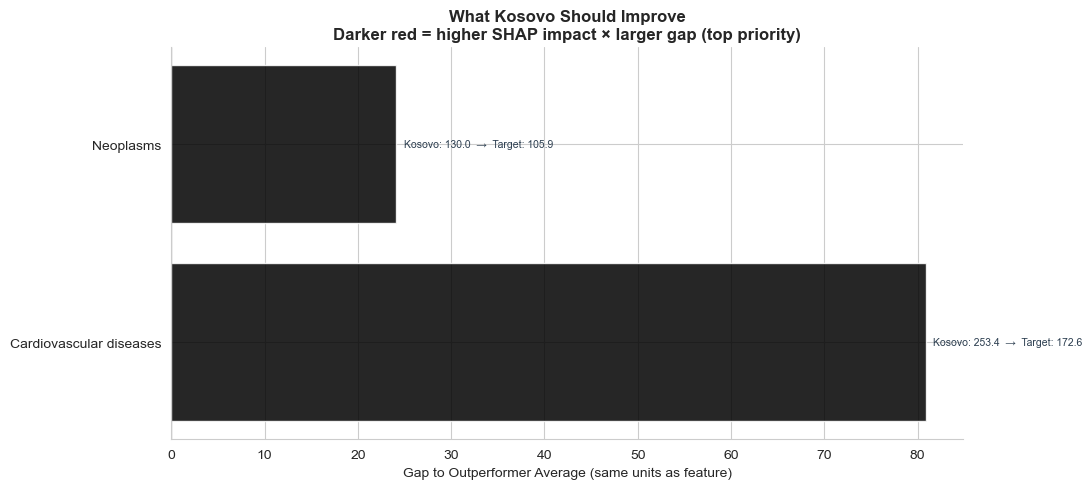


📋 TOP IMPROVEMENT PRIORITIES FOR KOSOVO:

  1. Reduce Neoplasms
     Current  : 129.99
     Target   : 105.86  (outperformer average)
     Gap      : 24.13

  2. Reduce Cardiovascular diseases
     Current  : 253.40
     Target   : 172.56  (outperformer average)
     Gap      : 80.84


In [16]:
# ── 5a. Improvement priorities — waterfall chart ──────────────────────────────

if CLUSTER_AVAILABLE and len(comparison_rows) > 0:

    # Ensure Outperformer Avg and country value are available in df_priority
    cols_to_merge = ['Feature', COUNTRY, 'Outperformer Avg', 'Lower is Better']
    df_gaps = df_priority.merge(
        df_comparison[cols_to_merge], on='Feature', how='left', suffixes=('', '_comp')
    )
    # Resolve any duplicate columns from the merge
    for col in ['Lower is Better']:
        if f'{col}_comp' in df_gaps.columns:
            df_gaps[col] = df_gaps[col].combine_first(df_gaps[f'{col}_comp'])
            df_gaps = df_gaps.drop(columns=[f'{col}_comp'])
    if f'{COUNTRY}_comp' in df_gaps.columns:
        df_gaps[COUNTRY] = df_gaps[COUNTRY].combine_first(df_gaps[f'{COUNTRY}_comp'])
        df_gaps = df_gaps.drop(columns=[f'{COUNTRY}_comp'])

    df_gaps = df_gaps[
        (df_gaps['Status'] == '⚠️ Gap') &
        (df_gaps['Gap to Outperformer'] > 0)
    ].head(10).copy()

    if len(df_gaps) == 0:
        print(f'✅ {COUNTRY} meets or exceeds outperformer average on all tracked features!')
    else:
        fig, ax = plt.subplots(figsize=(11, max(5, len(df_gaps) * 0.7)))

        # Color by priority score
        norm_scores = df_gaps['Priority Score'].values
        cmap   = plt.cm.RdYlGn_r
        ns     = (norm_scores - norm_scores.min()) / (norm_scores.max() - norm_scores.min() + 1e-9)
        colors = [cmap(n) for n in ns]

        bars = ax.barh(
            df_gaps['Feature'].values[::-1],
            df_gaps['Gap to Outperformer'].values[::-1],
            color=colors[::-1], alpha=0.85, edgecolor='white'
        )

        # Annotate with actual values
        for bar, (_, row) in zip(bars, df_gaps[::-1].iterrows()):
            country_val = row.get(COUNTRY, np.nan)
            target_val  = row.get('Outperformer Avg', np.nan)
            if pd.notna(country_val) and pd.notna(target_val):
                ax.text(
                    bar.get_width() + max(df_gaps['Gap to Outperformer'].max() * 0.01, 0.01),
                    bar.get_y() + bar.get_height() / 2,
                    f'{COUNTRY}: {country_val:.1f}  →  Target: {target_val:.1f}',
                    va='center', fontsize=7.5, color='#2c3e50'
                )

        ax.set_xlabel('Gap to Outperformer Average (same units as feature)')
        ax.set_title(f'What {COUNTRY} Should Improve\n'
                     'Darker red = higher SHAP impact × larger gap (top priority)',
                     fontweight='bold', fontsize=12)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.spines[['top', 'right']].set_visible(False)
        plt.tight_layout()
        fname = f'advisory_{COUNTRY.lower().replace(" ","_")}_improve.png'
        #plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        #print(f'✅ Saved: {fname}')

        # Narrative summary
        print(f'\n📋 TOP IMPROVEMENT PRIORITIES FOR {COUNTRY.upper()}:')
        print(f'{"="*70}')
        for i, (_, row) in enumerate(df_gaps.head(5).iterrows(), 1):
            direction   = 'Reduce' if row.get('Lower is Better', False) else 'Increase'
            country_val = row.get(COUNTRY, np.nan)
            target_val  = row.get('Outperformer Avg', np.nan)
            shap_val    = row.get('SHAP Importance', np.nan)
            print(f'\n  {i}. {direction} {row["Feature"]}')
            print(f'     Current  : {country_val:.2f}' if pd.notna(country_val) else '     Current  : N/A')
            print(f'     Target   : {target_val:.2f}  (outperformer average)' if pd.notna(target_val) else '     Target   : N/A')
            print(f'     Gap      : {row["Gap to Outperformer"]:.2f}')
            if SHAP_RANK_AVAILABLE and pd.notna(shap_val):
                print(f'     Impact   : SHAP={shap_val:.3f}  (model-validated importance)')

---
# **6. What to Protect — Existing Strengths**

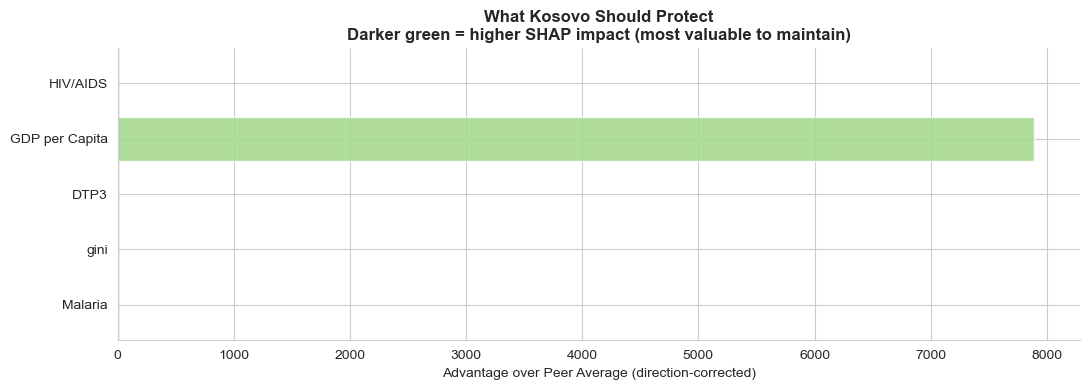


💪 STRENGTHS TO PROTECT — KOSOVO:
  ✅ HIV/AIDS
     Kosovo: 0.54  vs  Peer avg: 1.46  (below = better)
     Model impact: SHAP=0.417

  ✅ GDP per Capita
     Kosovo: 7900.00  vs  Peer avg: 9.02  (above = better)

  ✅ DTP3
     Kosovo: 90.31  vs  Peer avg: 88.65  (above = better)

  ✅ gini
     Kosovo: 0.33  vs  Peer avg: 0.39  (below = better)

  ✅ Malaria
     Kosovo: 0.00  vs  Peer avg: 0.10  (below = better)



In [17]:
# ── 6a. Strengths — features above peer average ───────────────────────────────

if CLUSTER_AVAILABLE and len(comparison_rows) > 0:

    df_strengths = df_comparison[
        df_comparison['Status'] == '✅ Strength'
    ].copy()

    # Add SHAP importance
    if SHAP_RANK_AVAILABLE:
        shap_map = df_shap_rank.set_index('Feature')['Mean_Abs_SHAP'].to_dict()
        df_strengths['SHAP Importance'] = df_strengths['Feature'].map(shap_map)
    else:
        df_strengths['SHAP Importance'] = np.nan

    df_strengths = df_strengths.sort_values('SHAP Importance', ascending=False, na_position='last')

    if len(df_strengths) == 0:
        print(f'⚠️  {COUNTRY} does not outperform peers on any tracked feature.')
    else:
        fig, ax = plt.subplots(figsize=(11, max(4, len(df_strengths) * 0.6)))

        # Advantage = country_val - peer_avg (direction-corrected)
        advantage = []
        for _, row in df_strengths.iterrows():
            lib = row['Lower is Better']
            adv = (row['Peer Average'] - row[COUNTRY]) if lib else (row[COUNTRY] - row['Peer Average'])
            advantage.append(adv)
        df_strengths['Advantage'] = advantage

        # Color by SHAP importance
        shap_vals = df_strengths['SHAP Importance'].fillna(0).values
        if shap_vals.max() > 0:
            ns     = shap_vals / shap_vals.max()
            colors = [plt.cm.YlGn(0.4 + 0.5 * n) for n in ns[::-1]]
        else:
            colors = ['#2ecc71'] * len(df_strengths)

        ax.barh(
            df_strengths['Feature'].values[::-1],
            df_strengths['Advantage'].values[::-1],
            color=colors, alpha=0.85, edgecolor='white'
        )
        ax.set_xlabel('Advantage over Peer Average (direction-corrected)')
        ax.set_title(f'What {COUNTRY} Should Protect\n'
                     'Darker green = higher SHAP impact (most valuable to maintain)',
                     fontweight='bold', fontsize=12)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.spines[['top', 'right']].set_visible(False)
        plt.tight_layout()
        fname = f'advisory_{COUNTRY.lower().replace(" ","_")}_protect.png'
        #plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        #print(f'✅ Saved: {fname}')

        print(f'\n💪 STRENGTHS TO PROTECT — {COUNTRY.upper()}:')
        print(f'{'='*70}')
        for _, row in df_strengths.head(5).iterrows():
            above = 'below' if row['Lower is Better'] else 'above'
            print(f'  ✅ {row["Feature"]}')
            print(f'     {COUNTRY}: {row[COUNTRY]:.2f}  vs  Peer avg: {row["Peer Average"]:.2f}  ({above} = better)')
            if not np.isnan(row.get('SHAP Importance', np.nan)):
                print(f'     Model impact: SHAP={row["SHAP Importance"]:.3f}')
            print()

---
# **6b. Mortality Burden Profile — What Is This Country Dying From?**

This section uses the **full cause-of-death columns** from the raw dataset — independent of the 10 model features — to answer:
- What are the top killers in this country right now?
- Which causes are above peer-group average (excess mortality)?
- Which are improving vs stagnating vs worsening over time?

> These deaths-by-cause columns were intentionally excluded from the ML feature set to preserve model parsimony and avoid multicollinearity. Here we use them directly for clinical diagnosis.


ℹ️  Using nearest-neighbour mortality profile for proxy country Kosovo.
Top 10 Causes of Death — Kosovo  (Deaths per 100,000 population)


,Cause of Death,Country Value,Peer Average,vs Peers (%),Status
0,Cardiovascular diseases,0.2020,0.2119,-4.6783,🟡 Similar
1,Neoplasms,0.1369,0.1052,30.0921,🔴 Above peers
2,Lower respiratory infections,0.0319,0.0294,8.4981,🟡 Similar
3,Chronic kidney disease,0.0282,0.0293,-3.7293,🟡 Similar
4,Alzheimer's disease and other dementias,0.0266,0.0173,53.6460,🔴 Above peers
5,Chronic respiratory diseases,0.0249,0.0345,-27.9043,🟢 Below peers
6,Digestive diseases,0.0208,0.0332,-37.3103,🟢 Below peers
7,Neonatal disorders,0.0152,0.0143,6.8236,🟡 Similar
8,Diabetes mellitus,0.0132,0.0353,-62.5220,🟢 Below peers
9,Cirrhosis and other chronic liver diseases,0.0117,0.0202,-41.7713,🟢 Below peers


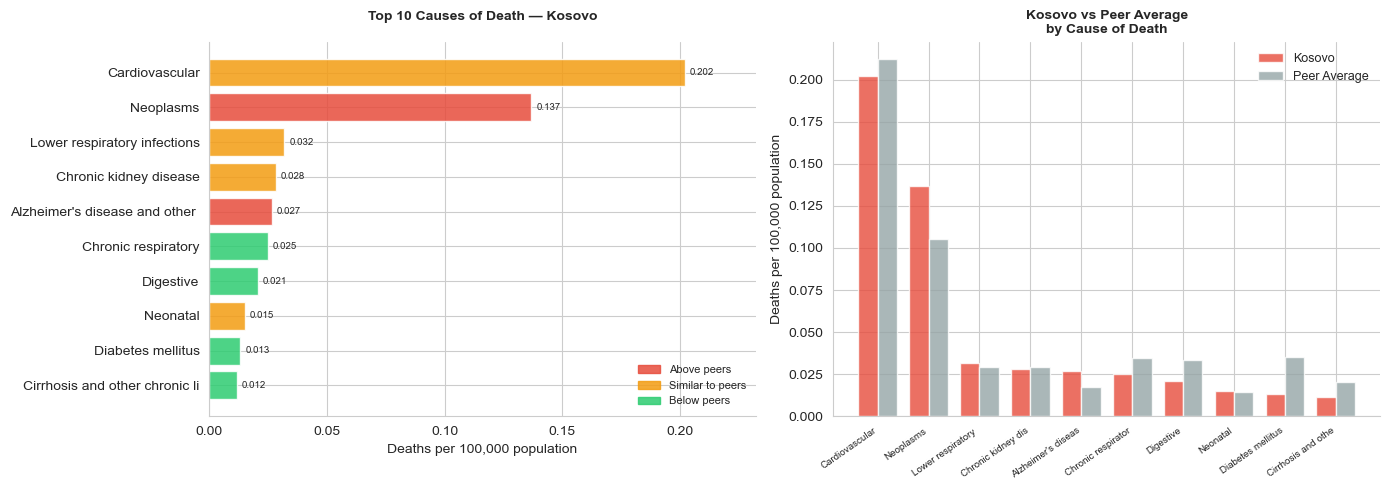

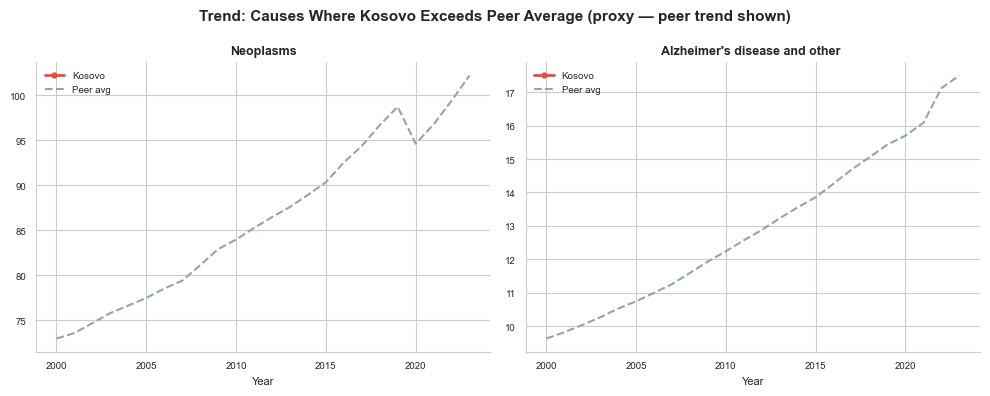


💀 MORTALITY DIAGNOSIS — KOSOVO
  #1 killer: Cardiovascular diseases
  #2 killer: Neoplasms
  #3 killer: Lower respiratory infections

  Excess mortality vs peers (above-average death rate):
    ⚠️  Neoplasms: ++30.1% above peer average
    ⚠️  Alzheimer's disease and other dementias: ++53.6% above peer average

  Already below peer average (keep protecting):
    ✅  Chronic respiratory diseases
    ✅  Digestive diseases
    ✅  Diabetes mellitus
    ✅  Cirrhosis and other chronic liver diseases


In [18]:
# ── 6b. Mortality burden profile ─────────────────────────────────────────────

# All death-cause columns in the dataset
DEATH_CAUSE_KEYWORDS = [
    'Cardiovascular', 'Neoplasms', 'Chronic respiratory', 'Diabetes',
    'Lower respiratory', 'Neonatal', 'Diarrheal', 'Tuberculosis',
    'HIV/AIDS', 'Malaria', 'Maternal', 'Conflict', 'Homicide',
    'Alcohol', 'Drug use', 'Road', 'Drowning', 'Nutritional',
    'Meningitis', 'Hepatitis', 'Alzheimer', 'Parkinson', 'Cirrhosis',
    'Kidney', 'Digestive', 'Protein', 'Self-harm', 'Poisoning',
    'Fire', 'Exposure', 'Environmental'
]

death_cols = [
    c for c in df_panel.columns
    if any(kw.lower() in c.lower() for kw in DEATH_CAUSE_KEYWORDS)
    and c not in ID_COLS
    and df_panel[c].dtype in ['float64', 'int64', 'Float64']
]

if len(death_cols) == 0:
    print('No cause-of-death columns found in dataset.')
else:
    # Recent average profile
    df_death_recent = df_panel[df_panel['Year'].isin(PROFILE_YEARS)]

    if IS_PROXY:
        # Proxy country: use nearest neighbour's death profile
        nn_country = df_panel[
            df_panel['Country'].isin(df_profile_all.head(1)['Country'].values)
            & df_panel['Year'].isin(PROFILE_YEARS)
        ]
        country_deaths = (
            nn_country[death_cols].mean()
            .dropna()
            .sort_values(ascending=False)
        )
        print(f'ℹ️  Using nearest-neighbour mortality profile for proxy country {COUNTRY}.')
    else:
        country_deaths = (
            df_death_recent[df_death_recent['Country'] == COUNTRY]
            [death_cols].mean()
            .dropna()
            .sort_values(ascending=False)
        )

    # Peer average deaths
    if CLUSTER_AVAILABLE:
        peer_deaths = (
            df_death_recent[df_death_recent['Country'].isin(df_peers['Country'])]
            [death_cols].mean()
        )
        # Normalise by population to get rates (divide by population if available)
        pop_col = 'Population' if 'Population' in df_panel.columns else None
        if pop_col:
            if IS_PROXY:
                country_pop = peer_pop = df_death_recent[
                    df_death_recent['Country'].isin(df_peers['Country'])
                ].groupby('Country')[pop_col].mean().mean()
            else:
                country_pop = df_death_recent[
                    df_death_recent['Country'] == COUNTRY][pop_col].mean()
                peer_pop = df_death_recent[
                    df_death_recent['Country'].isin(df_peers['Country'])
                ].groupby('Country')[pop_col].mean().mean()
            country_deaths_norm = country_deaths / country_pop * 100_000
            peer_deaths_norm    = peer_deaths    / peer_pop    * 100_000
            rate_label = 'Deaths per 100,000 population'
        else:
            country_deaths_norm = country_deaths
            peer_deaths_norm    = peer_deaths
            rate_label = 'Deaths (absolute — population data unavailable)'
    else:
        peer_deaths_norm    = pd.Series(dtype=float)
        country_deaths_norm = country_deaths
        rate_label = 'Deaths'

    # ── Table: top 10 causes + peer comparison ────────────────────────────────
    top10_causes = country_deaths_norm.head(10).index.tolist()

    if len(top10_causes) == 0:
        print(f'⚠️  No death cause data available for {COUNTRY} (proxy country — using peer average instead).')
        country_deaths_norm = peer_deaths_norm.copy()
        top10_causes = country_deaths_norm.head(10).index.tolist()

    burden_rows = []
    for cause in top10_causes:
        c_val = country_deaths_norm.get(cause, np.nan)
        p_val = peer_deaths_norm.get(cause, np.nan) if len(peer_deaths_norm) > 0 else np.nan
        if pd.notna(c_val) and pd.notna(p_val) and p_val > 0:
            pct_vs_peer = (c_val - p_val) / p_val * 100
            status = '🔴 Above peers' if pct_vs_peer > 10 else ('🟢 Below peers' if pct_vs_peer < -10 else '🟡 Similar')
        else:
            pct_vs_peer = np.nan
            status = '—'

        burden_rows.append({
            'Cause of Death'       : cause,
            'Country Value'        : round(c_val, 4) if pd.notna(c_val) else np.nan,
            'Peer Average'         : round(p_val, 4) if pd.notna(p_val) else np.nan,
            'vs Peers (%)'         : round(pct_vs_peer, 4) if pd.notna(pct_vs_peer) else np.nan,
            'Status'               : status,
        })

    df_burden = pd.DataFrame(burden_rows)
    print(f'Top 10 Causes of Death — {COUNTRY}  ({rate_label})')
    display(df_burden)

    # ── Chart A: stacked burden bar (country vs peer avg) ─────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: country top-10 horizontal bar
    ax = axes[0]
    vals   = df_burden['Country Value'].values[::-1]
    causes = [c.replace(' diseases','').replace(' disorders','')[:30]
              for c in df_burden['Cause of Death'].values[::-1]]
    status_colors = [
        '#e74c3c' if '🔴' in s else '#2ecc71' if '🟢' in s else '#f39c12'
        for s in df_burden['Status'].values[::-1]
    ]
    ax.barh(causes, vals, color=status_colors, alpha=0.85, edgecolor='white')
    ax.set_xlim(left=0, right=max(vals) * 1.15)

    # Add manual legend
    import matplotlib.patches as mpatches
    legend_patches = [
        mpatches.Patch(color='#e74c3c', alpha=0.85, label='Above peers'),
        mpatches.Patch(color='#f39c12', alpha=0.85, label='Similar to peers'),
        mpatches.Patch(color='#2ecc71', alpha=0.85, label='Below peers'),
    ]
    ax.legend(handles=legend_patches, fontsize=8, frameon=False, loc='lower right')

    # Add value labels on bars
    for i, v in enumerate(vals):
        if v > 0:
            ax.text(v + max(vals)*0.01, i, f'{v:.3f}', va='center', fontsize=7)

    ax.set_xlabel(rate_label)
    ax.set_title(f'Top 10 Causes of Death — {COUNTRY}\n',
                 fontweight='bold', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

    # Right: country vs peer avg for those same causes
    ax = axes[1]
    if len(peer_deaths_norm) > 0:
        x      = np.arange(len(top10_causes))
        w      = 0.38
        c_vals = [country_deaths_norm.get(c, 0) for c in top10_causes]
        p_vals = [peer_deaths_norm.get(c, 0)    for c in top10_causes]
        short  = [c.replace(' diseases','').replace(' disorders','')[:18]
                  for c in top10_causes]
        ax.bar(x - w/2, c_vals, w, label=COUNTRY,      color='#e74c3c', alpha=0.8, edgecolor='white')
        ax.bar(x + w/2, p_vals, w, label='Peer Average', color='#95a5a6', alpha=0.8, edgecolor='white')
        ax.set_xticks(x)
        ax.set_xticklabels(short, rotation=35, ha='right', fontsize=7)
        ax.set_ylabel(rate_label)
        ax.set_title(f'{COUNTRY} vs Peer Average\nby Cause of Death', fontweight='bold', fontsize=10)
        ax.legend(fontsize=9, frameon=False)
        ax.spines[['top', 'right']].set_visible(False)
    else:
        axes[1].axis('off')
        axes[1].text(0.5, 0.5, 'Peer data unavailable', ha='center', transform=axes[1].transAxes)

    plt.tight_layout()
    fname = f'advisory_{COUNTRY.lower().replace(" ","_")}_mortality_burden.png'
    #plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    #print(f'✅ Saved: {fname}')

    # ── Chart B: trend of top-3 excess causes over time ───────────────────────
    excess_causes = [
        r['Cause of Death'] for _, r in df_burden.iterrows()
        if r['Status'] == '🔴 Above peers'][:3]

    if excess_causes:
        fig, axes = plt.subplots(1, len(excess_causes),
                                  figsize=(5 * len(excess_causes), 4))
        if len(excess_causes) == 1:
            axes = [axes]

        df_trend_deaths = df_panel[df_panel['Year'].isin(TREND_YEARS)]

        for ax, cause in zip(axes, excess_causes):
            c_trend = df_trend_deaths[df_trend_deaths['Country'] == COUNTRY]\
                        .groupby('Year')[cause].mean()
            if CLUSTER_AVAILABLE:
                p_trend = df_trend_deaths[
                    df_trend_deaths['Country'].isin(df_peers['Country'])]\
                    .groupby('Year')[cause].mean()

            ax.plot(c_trend.index, c_trend.values, '-o', color='#e74c3c',
                    linewidth=2, markersize=3.5, label=COUNTRY)
            if CLUSTER_AVAILABLE and len(p_trend) > 0:
                ax.plot(p_trend.index, p_trend.values, '--',
                        color='#95a5a6', linewidth=1.5, label='Peer avg')
            short = cause.replace(' diseases','').replace(' disorders','')[:30]
            ax.set_title(short, fontweight='bold', fontsize=9)
            ax.set_xlabel('Year', fontsize=8)
            ax.legend(fontsize=7, frameon=False)
            ax.spines[['top', 'right']].set_visible(False)
            ax.tick_params(labelsize=7)

        proxy_note = ' (proxy — peer trend shown)' if IS_PROXY else ''
        plt.suptitle(f'Trend: Causes Where {COUNTRY} Exceeds Peer Average{proxy_note}', fontweight='bold', fontsize=11)
        plt.tight_layout()
        fname2 = f'advisory_{COUNTRY.lower().replace(" ","_")}_excess_causes_trend.png'
        #plt.savefig(fname2, dpi=150, bbox_inches='tight')
        plt.show()
        #print(f'✅ Saved: {fname2}')

    # ── Narrative ─────────────────────────────────────────────────────────────
    print(f'\n💀 MORTALITY DIAGNOSIS — {COUNTRY.upper()}')
    print('='*60)
    print(f'  #1 killer: {df_burden.iloc[0]["Cause of Death"]}')
    print(f'  #2 killer: {df_burden.iloc[1]["Cause of Death"]}')
    print(f'  #3 killer: {df_burden.iloc[2]["Cause of Death"]}')
    if excess_causes:
        print(f'\n  Excess mortality vs peers (above-average death rate):')
        for c in excess_causes:
            row = df_burden[df_burden['Cause of Death'] == c].iloc[0]
            print(f'    ⚠️  {c}: +{row["vs Peers (%)"]:+.1f}% above peer average')
    below = [r['Cause of Death'] for _, r in df_burden.iterrows() if r['Status'] == '🟢 Below peers']
    if below:
        print(f'\n  Already below peer average (keep protecting):')
        for c in below:
            print(f'    ✅  {c}')


---
# **6c. Vaccination Gap Analysis — Which Vaccines Is This Country Missing?**

The dataset contains coverage rates for up to 9 vaccines. We compare this country's coverage against:
- **WHO/UNICEF global target**: 95% coverage (herd immunity threshold for most EPI vaccines)
- **Peer cluster average**: what similar countries have achieved
- **Outperformer average**: what top-LE peers have achieved

Even vaccines not selected as model features can be critical — a coverage gap in a single high-burden vaccine can cause thousands of preventable deaths per year.


ℹ️  Using nearest-neighbour vaccination profile for proxy country Kosovo.
Vaccination Coverage — Kosovo vs WHO 95% target, Peers, Outperformers


,Vaccine,Full Name,Kosovo Coverage %,Peer Avg %,Outperf Avg %,Gap to WHO 95% target,Status
1,DTP1,"DTP1 (Diphtheria-Tetanus-Pertussis, 1st dose)",0.9,0.9,0.9,94.1,🔴 Critical gap (>25pp)
0,BCG,BCG (Tuberculosis),1.0,22.7,26.8,94.0,🔴 Critical gap (>25pp)
10,RotaC,"RotaC (Rotavirus, complete series)",40.0,10.1,7.2,55.0,🔴 Critical gap (>25pp)
6,MCV2,"MCV2 (Measles, 2nd dose)",61.2,22.7,27.8,33.8,🔴 Critical gap (>25pp)
8,Pol3,"Pol3 (Polio, 3rd dose)",65.5,88.1,89.6,29.5,🔴 Critical gap (>25pp)
3,HepB3,"HepB3 (Hepatitis B, 3rd dose)",68.7,25.2,30.5,26.3,🔴 Critical gap (>25pp)
4,Hib3,Hib3 (Haemophilus influenzae type b),72.0,23.3,25.1,23.0,🟠 Moderate gap (10–25pp)
2,DTP3,"DTP3 (Diphtheria-Tetanus-Pertussis, 3rd dose)",73.0,87.6,89.8,22.0,🟠 Moderate gap (10–25pp)
5,MCV1,"MCV1 (Measles, 1st dose)",73.2,23.8,30.8,21.8,🟠 Moderate gap (10–25pp)
9,RCV1,"RCV1 (Rubella, 1st dose)",73.2,89.3,90.4,21.8,🟠 Moderate gap (10–25pp)


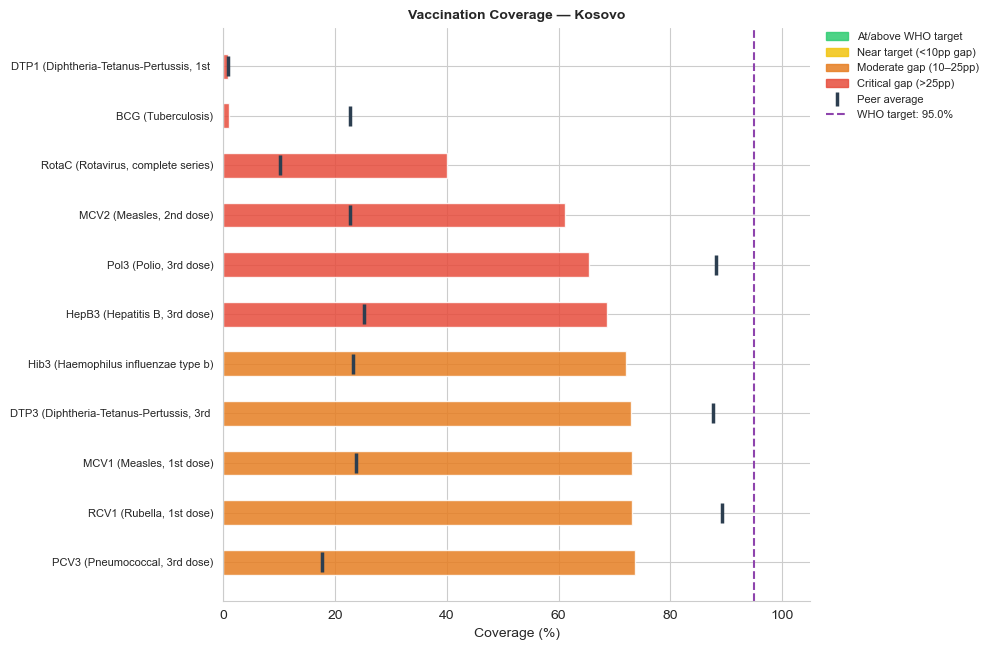

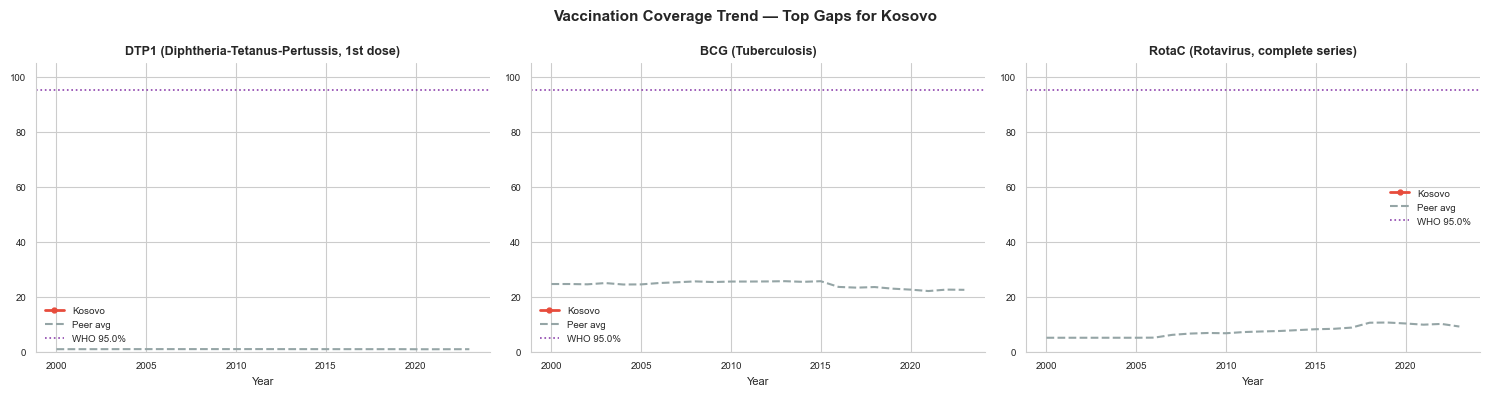


💉 VACCINATION DIAGNOSIS — KOSOVO
  Critical/moderate gaps (11 vaccines):
    🔴 DTP1 (Diphtheria-Tetanus-Pertussis, 1st dose)
       Coverage: 0.9%  |  Gap to WHO target: 94.1pp  (peers at 0.9%)
    🔴 BCG (Tuberculosis)
       Coverage: 1.0%  |  Gap to WHO target: 94.0pp  (peers at 22.7%)
    🔴 RotaC (Rotavirus, complete series)
       Coverage: 40.0%  |  Gap to WHO target: 55.0pp  (peers at 10.1%)
    🔴 MCV2 (Measles, 2nd dose)
       Coverage: 61.2%  |  Gap to WHO target: 33.8pp  (peers at 22.7%)
    🔴 Pol3 (Polio, 3rd dose)
       Coverage: 65.5%  |  Gap to WHO target: 29.5pp  (peers at 88.1%)
    🔴 HepB3 (Hepatitis B, 3rd dose)
       Coverage: 68.7%  |  Gap to WHO target: 26.3pp  (peers at 25.2%)
    🟠 Hib3 (Haemophilus influenzae type b)
       Coverage: 72.0%  |  Gap to WHO target: 23.0pp  (peers at 23.3%)
    🟠 DTP3 (Diphtheria-Tetanus-Pertussis, 3rd dose)
       Coverage: 73.0%  |  Gap to WHO target: 22.0pp  (peers at 87.6%)
    🟠 MCV1 (Measles, 1st dose)
       Coverage: 73.2

In [19]:
# ── 6c. Vaccination gap analysis ─────────────────────────────────────────────

VACCINE_COLS = [c for c in df_panel.columns
                if c in ['BCG','DTP1','DTP3','HepB3','Hib3',
                          'MCV1','MCV2','PCV3','Pol3','RCV1','RotaC',
                          'IPV1','Polio3']]

VACCINE_FULL_NAMES = {
    'BCG'   : 'BCG (Tuberculosis)',
    'DTP1'  : 'DTP1 (Diphtheria-Tetanus-Pertussis, 1st dose)',
    'DTP3'  : 'DTP3 (Diphtheria-Tetanus-Pertussis, 3rd dose)',
    'HepB3' : 'HepB3 (Hepatitis B, 3rd dose)',
    'Hib3'  : 'Hib3 (Haemophilus influenzae type b)',
    'MCV1'  : 'MCV1 (Measles, 1st dose)',
    'MCV2'  : 'MCV2 (Measles, 2nd dose)',
    'PCV3'  : 'PCV3 (Pneumococcal, 3rd dose)',
    'Pol3'  : 'Pol3 (Polio, 3rd dose)',
    'RCV1'  : 'RCV1 (Rubella, 1st dose)',
    'RotaC' : 'RotaC (Rotavirus, complete series)',
}
WHO_TARGET = 95.0   # % coverage — WHO/UNICEF global EPI target

if len(VACCINE_COLS) == 0:
    print('No vaccine coverage columns found in dataset.')
else:
    df_vax_recent = df_panel[df_panel['Year'].isin(PROFILE_YEARS)]

    if IS_PROXY:
        nn_country_vax = df_vax_recent[
            df_vax_recent['Country'].isin(df_profile_all.head(1)['Country'].values)
        ]
        country_vax = nn_country_vax[VACCINE_COLS].mean()
        print(f'ℹ️  Using nearest-neighbour vaccination profile for proxy country {COUNTRY}.')
    else:
        country_vax = df_vax_recent[df_vax_recent['Country'] == COUNTRY][VACCINE_COLS].mean()

    if CLUSTER_AVAILABLE:
        peer_vax     = df_vax_recent[df_vax_recent['Country'].isin(
            df_peers['Country'])][VACCINE_COLS].mean()
        outperf_vax  = df_vax_recent[df_vax_recent['Country'].isin(
            outperformers['Country'])][VACCINE_COLS].mean() if len(outperformers) > 0 else pd.Series(dtype=float)
    else:
        peer_vax, outperf_vax = pd.Series(dtype=float), pd.Series(dtype=float)

    global_vax = df_vax_recent[VACCINE_COLS].mean()

    vax_rows = []
    for v in VACCINE_COLS:
        c_val = country_vax.get(v, np.nan)
        if pd.isna(c_val):
            continue
        p_val  = peer_vax.get(v, np.nan)    if len(peer_vax) > 0    else np.nan
        op_val = outperf_vax.get(v, np.nan) if len(outperf_vax) > 0 else np.nan
        g_val  = global_vax.get(v, np.nan)

        gap_to_target = WHO_TARGET - c_val
        gap_to_peer   = (p_val - c_val)  if pd.notna(p_val)  else np.nan
        gap_to_outperf= (op_val - c_val) if pd.notna(op_val) else np.nan

        if c_val >= WHO_TARGET:
            status = '✅ At/above target'
        elif c_val >= WHO_TARGET - 10:
            status = '🟡 Near target (<10pp gap)'
        elif c_val >= WHO_TARGET - 25:
            status = '🟠 Moderate gap (10–25pp)'
        else:
            status = '🔴 Critical gap (>25pp)'

        vax_rows.append({
            'Vaccine'               : v,
            'Full Name'             : VACCINE_FULL_NAMES.get(v, v),
            f'{COUNTRY} Coverage %' : round(c_val, 1),
            'Peer Avg %'            : round(p_val, 1)   if pd.notna(p_val)   else np.nan,
            'Outperf Avg %'         : round(op_val, 1)  if pd.notna(op_val)  else np.nan,
            'Global Avg %'          : round(g_val, 1)   if pd.notna(g_val)   else np.nan,
            'Gap to WHO 95% target' : round(gap_to_target, 1),
            'Gap to Peer Avg'       : round(gap_to_peer, 1) if pd.notna(gap_to_peer) else np.nan,
            'Status'                : status,
        })

    df_vax = pd.DataFrame(vax_rows).sort_values('Gap to WHO 95% target', ascending=False)

    print(f'Vaccination Coverage — {COUNTRY} vs WHO 95% target, Peers, Outperformers')
    display(df_vax[['Vaccine','Full Name',f'{COUNTRY} Coverage %',
                     'Peer Avg %','Outperf Avg %','Gap to WHO 95% target','Status']])

    # ── Chart: coverage heatmap-style bar ─────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, max(4, len(df_vax) * 0.6)))

    vaccines  = df_vax['Vaccine'].tolist()[::-1]
    c_vals    = df_vax[f'{COUNTRY} Coverage %'].tolist()[::-1]
    p_vals    = df_vax['Peer Avg %'].tolist()[::-1]

    bar_colors = []
    for s in df_vax['Status'].tolist()[::-1]:
        if '✅' in s:   bar_colors.append('#2ecc71')
        elif '🟡' in s: bar_colors.append('#f1c40f')
        elif '🟠' in s: bar_colors.append('#e67e22')
        else:           bar_colors.append('#e74c3c')

    y_pos = np.arange(len(vaccines))
    ax.barh(y_pos, c_vals, height=0.5, color=bar_colors, alpha=0.85,
            edgecolor='white', label=COUNTRY)

    # Peer average markers
    if len(peer_vax) > 0:
        ax.scatter(p_vals, y_pos, marker='|', s=200, color='#2c3e50',
                   linewidths=2.5, zorder=5, label='Peer average')

    # WHO 95% target line
    ax.axvline(WHO_TARGET, color='#8e44ad', linestyle='--', linewidth=1.5,
               label=f'WHO target: {WHO_TARGET}%')

    ax.set_yticks(y_pos)
    ax.set_yticklabels([VACCINE_FULL_NAMES.get(v, v)[:40] for v in vaccines], fontsize=8)
    ax.set_xlabel('Coverage (%)')
    ax.set_xlim(0, 105)
    ax.set_title(f'Vaccination Coverage — {COUNTRY}', fontweight='bold', fontsize=10)

    # Main legend — country bar, peer marker, WHO line

    combined_handles = [
        mpatches.Patch(color='#2ecc71', alpha=0.85, label='At/above WHO target'),
        mpatches.Patch(color='#f1c40f', alpha=0.85, label='Near target (<10pp gap)'),
        mpatches.Patch(color='#e67e22', alpha=0.85, label='Moderate gap (10–25pp)'),
        mpatches.Patch(color='#e74c3c', alpha=0.85, label='Critical gap (>25pp)'),
        mlines.Line2D([], [], color='#2c3e50', marker='|', markersize=10,
                      linewidth=0, markeredgewidth=2.5, label='Peer average'),
        mlines.Line2D([], [], color='#8e44ad', linestyle='--',
                      linewidth=1.5, label=f'WHO target: {WHO_TARGET}%'),
    ]
    ax.legend(handles=combined_handles, fontsize=8, frameon=False,
              loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
    plt.tight_layout(rect=[0, 0, 0.82, 1])  # leave room on right for legend

    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    fname = f'advisory_{COUNTRY.lower().replace(" ","_")}_vaccination_gaps.png'
    #plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    #print(f'✅ Saved: {fname}')

    # ── Trend for the 2–3 most critical vaccine gaps ───────────────────────────
    critical_vax = df_vax[df_vax['Gap to WHO 95% target'] > 0]['Vaccine'].head(3).tolist()
    critical_vax = [v for v in critical_vax if v in df_panel.columns]

    if critical_vax:
        fig, axes = plt.subplots(1, len(critical_vax),
                                  figsize=(5 * len(critical_vax), 4))
        if len(critical_vax) == 1:
            axes = [axes]

        df_vax_trend = df_panel[df_panel['Year'].isin(TREND_YEARS)]
        for ax, vax in zip(axes, critical_vax):
            c_trend = df_vax_trend[df_vax_trend['Country'] == COUNTRY]\
                        .groupby('Year')[vax].mean()
            ax.plot(c_trend.index, c_trend.values, '-o', color='#e74c3c',
                    linewidth=2, markersize=3.5, label=COUNTRY)
            if CLUSTER_AVAILABLE:
                p_t = df_vax_trend[df_vax_trend['Country'].isin(
                    df_peers['Country'])].groupby('Year')[vax].mean()
                ax.plot(p_t.index, p_t.values, '--', color='#95a5a6',
                        linewidth=1.5, label='Peer avg')
            ax.axhline(WHO_TARGET, color='#8e44ad', linestyle=':',
                       linewidth=1.2, label=f'WHO {WHO_TARGET}%')
            ax.set_ylim(0, 105)
            ax.set_title(VACCINE_FULL_NAMES.get(vax, vax), fontweight='bold', fontsize=9)
            ax.set_xlabel('Year', fontsize=8)
            ax.legend(fontsize=7, frameon=False)
            ax.spines[['top', 'right']].set_visible(False)
            ax.tick_params(labelsize=7)

        plt.suptitle(f'Vaccination Coverage Trend — Top Gaps for {COUNTRY}',
                     fontweight='bold', fontsize=11)
        plt.tight_layout()
        fname2 = f'advisory_{COUNTRY.lower().replace(" ","_")}_vaccine_trend.png'
        #plt.savefig(fname2, dpi=150, bbox_inches='tight')
        plt.show()
        #print(f'✅ Saved: {fname2}')

    # ── Narrative ─────────────────────────────────────────────────────────────
    critical = df_vax[df_vax['Status'].str.contains('🔴|🟠')]
    at_target = df_vax[df_vax['Status'].str.contains('✅')]

    print(f'\n💉 VACCINATION DIAGNOSIS — {COUNTRY.upper()}')
    print('='*60)
    if len(critical) > 0:
        print(f'  Critical/moderate gaps ({len(critical)} vaccines):')
        for _, r in critical.iterrows():
            gap_peer_str = f"  (peers at {r['Peer Avg %']:.1f}%)" if pd.notna(r['Peer Avg %']) else ''
            print(f"    {'🔴' if '🔴' in r['Status'] else '🟠'} {r['Full Name']}")
            print(f"       Coverage: {r[f'{COUNTRY} Coverage %']:.1f}%  |  "
                  f"Gap to WHO target: {r['Gap to WHO 95% target']:.1f}pp{gap_peer_str}")
    else:
        print(f'  ✅ All vaccines at or near WHO 95% target!')

    if len(at_target) > 0:
        print(f'\n  Already at/above WHO target ({len(at_target)} vaccines):')
        print(f"    {', '.join(at_target['Vaccine'].tolist())}")


---
# **6d. Poverty & Inequality Lens**

The model uses Gini as a single inequality feature. But the full poverty staircase — from extreme poverty ($2.15/day) through middle-income thresholds ($20/day, $40/day) — and income distribution metrics tell a richer story about *who* within the country will benefit from interventions and *where* health spending will have the most leverage.

High inequality means that even country-level average improvements may leave the poorest quintile behind — and the poorest quintile typically has the worst health outcomes.


ℹ️  Using nearest-neighbour poverty profile for proxy country Kosovo.
Poverty & Inequality Profile — Kosovo


,Indicator,Country Value,Peer Avg,Outperf Avg,Status
0,Extreme poverty (<$2.15/day),0.000,4.848,1.394,✅ Better than peers
1,Low income (<$3.65/day),0.061,13.732,4.816,✅ Better than peers
2,Lower-middle (<$6.85/day),1.682,36.049,20.098,✅ Better than peers
3,Working poor (<$20/day),31.706,81.833,70.847,✅ Better than peers
4,Near-middle (<$40/day),78.181,95.115,91.007,✅ Better than peers
5,Mean income ($/day),30.786,13.857,19.017,✅ Better than peers
6,Median income ($/day),26.117,10.273,13.876,✅ Better than peers
7,Gini coefficient,0.318,0.391,0.403,✅ Better than peers
8,Palma ratio (top10/bottom40),1.207,1.925,2.058,✅ Better than peers
9,P90/P10 ratio,4.233,6.120,6.613,✅ Better than peers


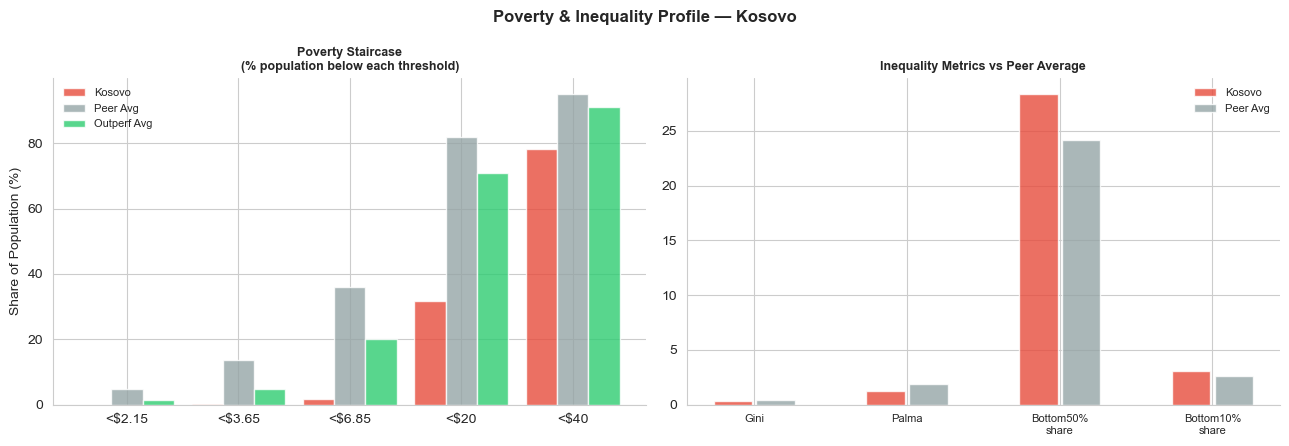


📊 INEQUALITY DIAGNOSIS — KOSOVO

  Inequality dimensions better than peers:
    ✅  Extreme poverty (<$2.15/day): 0.0 vs peer avg 4.848
    ✅  Low income (<$3.65/day): 0.061 vs peer avg 13.732
    ✅  Lower-middle (<$6.85/day): 1.682 vs peer avg 36.049
    ✅  Working poor (<$20/day): 31.706 vs peer avg 81.833
    ✅  Near-middle (<$40/day): 78.181 vs peer avg 95.115
    ✅  Mean income ($/day): 30.786 vs peer avg 13.857
    ✅  Median income ($/day): 26.117 vs peer avg 10.273
    ✅  Gini coefficient: 0.318 vs peer avg 0.391
    ✅  Palma ratio (top10/bottom40): 1.207 vs peer avg 1.925
    ✅  P90/P10 ratio: 4.233 vs peer avg 6.12
    ✅  Bottom 50% income share: 28.401 vs peer avg 24.212
    ✅  Bottom 10% income share: 3.091 vs peer avg 2.589
    ✅  Top 10% income share: 24.789 vs peer avg 30.664


In [20]:
# ── 6d. Poverty & inequality lens ────────────────────────────────────────────

POVERTY_COLS = {
    'Share below $2.15 a day'              : 'Extreme poverty (<$2.15/day)',
    'Share below $3.65 a day'              : 'Low income (<$3.65/day)',
    'Share below $6.85 a day'              : 'Lower-middle (<$6.85/day)',
    'Share below $20 a day'                : 'Working poor (<$20/day)',
    'Share below $40 a day'                : 'Near-middle (<$40/day)',
    'Mean income or consumption per day'   : 'Mean income ($/day)',
    'Median income or consumption per day' : 'Median income ($/day)',
    'gini'                                 : 'Gini coefficient',
    'palma_ratio'                          : 'Palma ratio (top10/bottom40)',
    'p90_p10_ratio'                        : 'P90/P10 ratio',
    'bottom50_share'                       : 'Bottom 50% income share',
    'decile1_share'                        : 'Bottom 10% income share',
    'decile10_share'                       : 'Top 10% income share',
}

avail_pov = {k: v for k, v in POVERTY_COLS.items() if k in df_panel.columns}

if len(avail_pov) == 0:
    print('No poverty/inequality columns found in dataset.')
else:
    df_pov_recent = df_panel[df_panel['Year'].isin(PROFILE_YEARS)]

    if IS_PROXY:
        nn_country_pov = df_pov_recent[
            df_pov_recent['Country'].isin(df_profile_all.head(1)['Country'].values)
        ]
        country_pov = nn_country_pov[list(avail_pov.keys())].mean()
        print(f'ℹ️  Using nearest-neighbour poverty profile for proxy country {COUNTRY}.')
    else:
        country_pov = df_pov_recent[df_pov_recent['Country'] == COUNTRY]\
                        [list(avail_pov.keys())].mean()

    if CLUSTER_AVAILABLE:
        peer_pov    = df_pov_recent[df_pov_recent['Country'].isin(
            df_peers['Country'])][list(avail_pov.keys())].mean()
        outperf_pov = df_pov_recent[df_pov_recent['Country'].isin(
            outperformers['Country'])][list(avail_pov.keys())].mean() \
            if len(outperformers) > 0 else pd.Series(dtype=float)
    else:
        peer_pov, outperf_pov = pd.Series(dtype=float), pd.Series(dtype=float)

    # Build comparison table
    pov_rows = []
    for col, label in avail_pov.items():
        c_val = country_pov.get(col, np.nan)
        p_val = peer_pov.get(col, np.nan)    if len(peer_pov) > 0    else np.nan
        o_val = outperf_pov.get(col, np.nan) if len(outperf_pov) > 0 else np.nan
        if pd.isna(c_val):
            continue

        # For poverty shares and inequality: lower is better
        # For income shares of bottom 50%, bottom 10%: higher is better
        lower_better = col not in ['bottom50_share', 'decile1_share',
                                    'Mean income or consumption per day',
                                    'Median income or consumption per day']

        if pd.notna(p_val) and p_val != 0:
            diff = c_val - p_val
            worse_than_peer = (diff > 0) if lower_better else (diff < 0)
            status = '⚠️ Worse than peers' if worse_than_peer else '✅ Better than peers'
        else:
            status = '—'

        pov_rows.append({
            'Indicator'       : label,
            'Country Value'   : round(c_val, 3),
            'Peer Avg'        : round(p_val, 3)  if pd.notna(p_val) else np.nan,
            'Outperf Avg'     : round(o_val, 3)  if pd.notna(o_val) else np.nan,
            'Status'          : status,
        })

    df_pov_table = pd.DataFrame(pov_rows)
    print(f'Poverty & Inequality Profile — {COUNTRY}')
    display(df_pov_table)

    # ── Chart: poverty staircase ──────────────────────────────────────────────
    staircase_cols = [
        k for k in ['Share below $2.15 a day', 'Share below $3.65 a day',
                     'Share below $6.85 a day', 'Share below $20 a day',
                     'Share below $40 a day']
        if k in avail_pov
    ]
    staircase_labels = ['<$2.15', '<$3.65', '<$6.85', '<$20', '<$40']
    staircase_labels = staircase_labels[:len(staircase_cols)]

    if len(staircase_cols) >= 2:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

        # Left: poverty staircase
        ax = axes[0]
        c_stair = [country_pov.get(c, np.nan) for c in staircase_cols]
        p_stair = [peer_pov.get(c, np.nan)    for c in staircase_cols] if len(peer_pov) > 0 else []
        o_stair = [outperf_pov.get(c, np.nan) for c in staircase_cols] if len(outperf_pov) > 0 else []

        x = np.arange(len(staircase_labels))
        w = 0.28
        ax.bar(x - w, c_stair, w, label=COUNTRY,         color='#e74c3c', alpha=0.8, edgecolor='white')
        if p_stair:
            ax.bar(x,     p_stair, w, label='Peer Avg',  color='#95a5a6', alpha=0.8, edgecolor='white')
        if o_stair:
            ax.bar(x + w, o_stair, w, label='Outperf Avg', color='#2ecc71', alpha=0.8, edgecolor='white')

        ax.set_xticks(x)
        ax.set_xticklabels(staircase_labels)
        ax.set_ylabel('Share of Population (%)')
        ax.set_title('Poverty Staircase\n(% population below each threshold)',
                     fontweight='bold', fontsize=9)
        ax.legend(fontsize=8, frameon=False)
        ax.spines[['top', 'right']].set_visible(False)

        # Right: inequality metrics
        ax = axes[1]
        ineq_cols_plot = {
            'gini': 'Gini', 'palma_ratio': 'Palma',
            'bottom50_share': 'Bottom50%\nshare', 'decile1_share': 'Bottom10%\nshare'
        }
        avail_ineq = {k: v for k, v in ineq_cols_plot.items() if k in avail_pov}

        if avail_ineq:
            xi = np.arange(len(avail_ineq))
            c_ineq = [country_pov.get(k, np.nan) for k in avail_ineq]
            p_ineq = [peer_pov.get(k, np.nan)    for k in avail_ineq] if len(peer_pov) > 0 else []
            ax.bar(xi - w/2, c_ineq, w*0.9, label=COUNTRY,
                   color='#e74c3c', alpha=0.8, edgecolor='white')
            if p_ineq:
                ax.bar(xi + w/2, p_ineq, w*0.9, label='Peer Avg',
                       color='#95a5a6', alpha=0.8, edgecolor='white')
            ax.set_xticks(xi)
            ax.set_xticklabels(list(avail_ineq.values()), fontsize=8)
            ax.set_title('Inequality Metrics vs Peer Average',
                         fontweight='bold', fontsize=9)
            ax.legend(fontsize=8, frameon=False)
            ax.spines[['top', 'right']].set_visible(False)
        else:
            axes[1].axis('off')

        plt.suptitle(f'Poverty & Inequality Profile — {COUNTRY}',
                     fontweight='bold', fontsize=12)
        plt.tight_layout()
        fname = f'advisory_{COUNTRY.lower().replace(" ","_")}_poverty_inequality.png'
        #plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        #print(f'✅ Saved: {fname}')

    # ── Narrative ─────────────────────────────────────────────────────────────
    print(f'\n📊 INEQUALITY DIAGNOSIS — {COUNTRY.upper()}')
    print('='*60)
    worse = df_pov_table[df_pov_table['Status'] == '⚠️ Worse than peers']
    better = df_pov_table[df_pov_table['Status'] == '✅ Better than peers']
    if len(worse) > 0:
        print(f'  Inequality dimensions worse than peers:')
        for _, r in worse.iterrows():
            print(f'    ⚠️  {r["Indicator"]}: {r['Country Value']} vs peer avg {r["Peer Avg"]}')
    if len(better) > 0:
        print(f'\n  Inequality dimensions better than peers:')
        for _, r in better.iterrows():
            print(f'    ✅  {r["Indicator"]}: {r['Country Value']} vs peer avg {r["Peer Avg"]}')

    # Key policy implication
    ext_pov = country_pov.get('Share below $2.15 a day', np.nan)
    gini_val = country_pov.get('gini', np.nan)
    if pd.notna(ext_pov) and ext_pov > 10:
        print(f'\n  🔑 Policy implication: {ext_pov:.1f}% of the population lives below $2.15/day.')
        print(f'     Universal health interventions will not reach this group without')
        print(f'     targeted social protection (cash transfers, community health workers).')
    if pd.notna(gini_val) and gini_val > 0.40:
        print(f'\n  🔑 High inequality (Gini={gini_val:.2f}): average LE improvements may mask')
        print(f'     large within-country disparities. Equity-weighted metrics recommended.')


---
# **7. Historical Trend — Progress on Key Indicators**

ℹ️  Using nearest-neighbour LE trend for proxy country Kosovo (Lebanon).


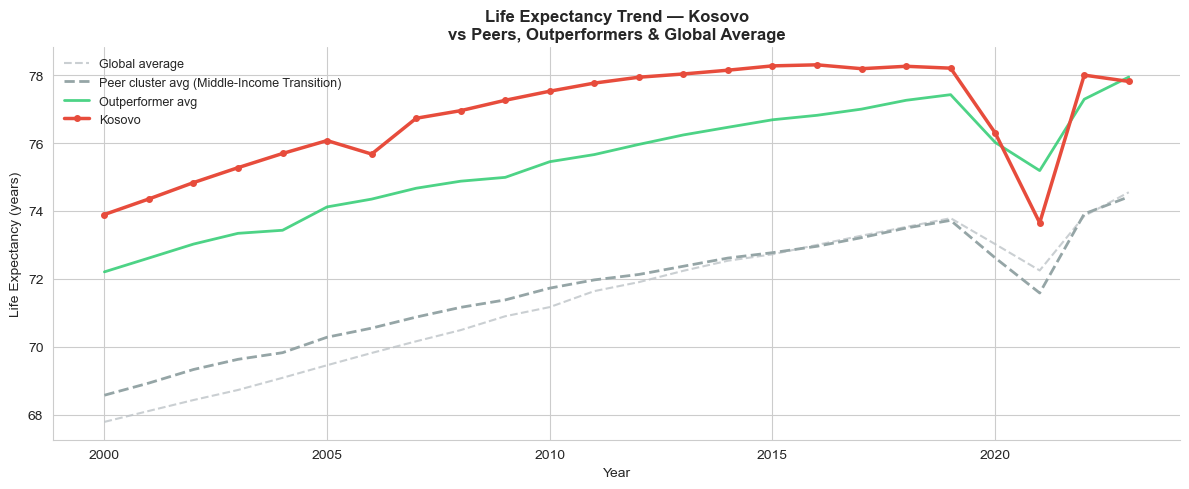


LE progress (2000–2023): 73.9 → 77.8 years  (+3.9)


In [21]:
# ── 7a. LE trend — country vs peers vs global ─────────────────────────────────

df_trend = df_panel[df_panel['Year'].isin(TREND_YEARS)].copy()

if IS_PROXY:
    nn_c = df_profile_all.head(1)['Country'].values[0]
    le_country = df_trend[df_trend['Country'] == nn_c].groupby('Year')[TARGET].mean()
    print(f'ℹ️  Using nearest-neighbour LE trend for proxy country {COUNTRY} ({nn_c}).')
else:
    le_country = df_trend[df_trend['Country'] == COUNTRY].groupby('Year')[TARGET].mean()
le_global  = df_trend.groupby('Year')[TARGET].mean()

if CLUSTER_AVAILABLE:
    peer_countries = df_peers['Country'].tolist()
    le_peers = df_trend[df_trend['Country'].isin(peer_countries)].groupby('Year')[TARGET].mean()
    le_outperf = (
        df_trend[df_trend['Country'].isin(outperformers['Country'].tolist())]
        .groupby('Year')[TARGET].mean()
    ) if len(outperformers) > 0 else pd.Series(dtype=float)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(le_global.index, le_global.values, '--', color='#bdc3c7',
        linewidth=1.5, label='Global average', alpha=0.8)
if CLUSTER_AVAILABLE and len(le_peers) > 0:
    ax.plot(le_peers.index, le_peers.values, '--', color='#95a5a6',
            linewidth=2, label=f'Peer cluster avg ({cluster_label})')
if CLUSTER_AVAILABLE and len(le_outperf) > 0:
    ax.plot(le_outperf.index, le_outperf.values, '-', color='#2ecc71',
            linewidth=2, label='Outperformer avg', alpha=0.85)
ax.plot(le_country.index, le_country.values, '-o', color='#e74c3c',
        linewidth=2.5, markersize=4, label=COUNTRY, zorder=5)

ax.set_xlabel('Year')
ax.set_ylabel('Life Expectancy (years)')
ax.set_title(f'Life Expectancy Trend — {COUNTRY}\nvs Peers, Outperformers & Global Average',
             fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
fname = f'advisory_{COUNTRY.lower().replace(" ","_")}_le_trend.png'
#plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
#print(f'✅ Saved: {fname}')

# Progress stats
le_2000 = le_country.iloc[0] if len(le_country) > 0 else np.nan
le_now  = le_country.iloc[-1] if len(le_country) > 0 else np.nan
print(f'\nLE progress ({int(le_country.index[0])}–{int(le_country.index[-1])}): '
      f'{le_2000:.1f} → {le_now:.1f} years  ({le_now - le_2000:+.1f})')

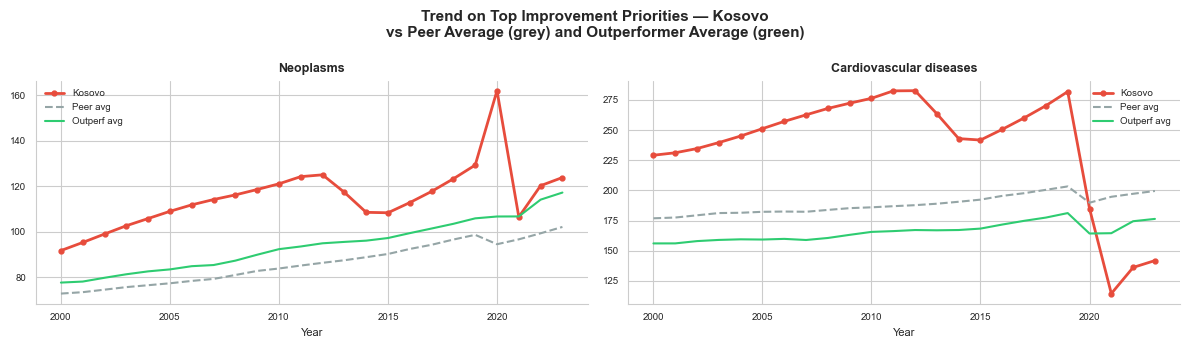

In [22]:
# ── 7b. Trend on top improvement priorities ────────────────────────────────────

if CLUSTER_AVAILABLE and len(comparison_rows) > 0:

    top_feats = df_gaps['Feature'].head(4).tolist() if len(df_gaps) > 0 else []
    top_feats = [f for f in top_feats if f in df_panel.columns]

    if len(top_feats) > 0:
        ncols = 2
        nrows = int(np.ceil(len(top_feats) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 3.5))
        axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes.flatten()

        for ax, feat in zip(axes, top_feats):
            if IS_PROXY:
                nn_c = df_profile_all.head(1)['Country'].values[0]
                c_trend = df_trend[df_trend['Country'] == nn_c].groupby('Year')[feat].mean()
            else:
                c_trend = df_trend[df_trend['Country'] == COUNTRY].groupby('Year')[feat].mean()
            p_trend = df_trend[df_trend['Country'].isin(peer_countries)].groupby('Year')[feat].mean()
            o_trend = (
                df_trend[df_trend['Country'].isin(outperformers['Country'].tolist())]
                .groupby('Year')[feat].mean()
            ) if len(outperformers) > 0 else pd.Series(dtype=float)

            ax.plot(c_trend.index, c_trend.values, '-o', color='#e74c3c',
                    linewidth=2, markersize=3.5, label=COUNTRY)
            if len(p_trend) > 0:
                ax.plot(p_trend.index, p_trend.values, '--', color='#95a5a6',
                        linewidth=1.5, label='Peer avg')
            if len(o_trend) > 0:
                ax.plot(o_trend.index, o_trend.values, '-', color='#2ecc71',
                        linewidth=1.5, label='Outperf avg')

            ax.set_title(feat, fontweight='bold', fontsize=9)
            ax.set_xlabel('Year', fontsize=8)
            ax.legend(fontsize=7, frameon=False)
            ax.tick_params(labelsize=7)
            ax.spines[['top', 'right']].set_visible(False)

        for ax in axes[len(top_feats):]:
            ax.set_visible(False)

        plt.suptitle(f'Trend on Top Improvement Priorities — {COUNTRY}\n'
                     'vs Peer Average (grey) and Outperformer Average (green)',
                     fontsize=11, fontweight='bold')
        plt.tight_layout()
        fname = f'advisory_{COUNTRY.lower().replace(" ","_")}_indicator_trends.png'
        #plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        #print(f'✅ Saved: {fname}')

---
# **8. Scenario Simulation — What Happens If Gaps Are Closed?**

Using the trained Phase C model, we simulate what the model predicts for LE if the country closes a fraction of its gap to outperformer averages on its top priority features.

In [23]:
# ── 8a. Scenario construction ─────────────────────────────────────────────────

if not MODEL_AVAILABLE:
    print('Phase C model not available — skipping scenario simulation.')
    print('Run phase_c_modeling.ipynb first.')
    df_scenarios = pd.DataFrame()

elif not CLUSTER_AVAILABLE:
    print(f'{COUNTRY} cluster data unavailable — no scenarios to simulate.')
    df_scenarios = pd.DataFrame()

else:
    # Build current feature vector for the country
    current_vals = {}
    for feat in feature_cols:
        base_feat = feat.replace('_lag1', '').replace('_lag2', '').replace('_lag3', '')
        val = country_profile.get(feat, country_profile.get(base_feat, np.nan))
        current_vals[feat] = val

    current_vec        = np.array([current_vals.get(f, 0) for f in feature_cols]).reshape(1, -1)
    current_vec_scaled = scaler.transform(current_vec)
    baseline_pred      = float(best_model.predict(current_vec_scaled)[0])

    print(f'\nBaseline prediction for {COUNTRY}: {baseline_pred:.1f} years')
    print(f'Actual LE ({latest_year}): {latest_le_val:.1f} years')
    print(f'Model delta: {baseline_pred - latest_le_val:+.1f} years')

    # ── Find actionable features ──────────────────────────────────────────────
    model_feats = [f.replace('_lag1','').replace('_lag2','').replace('_lag3','')
                   for f in feature_cols]

    # Priority 1: df_gaps features that overlap with model features
    actionable = df_gaps[df_gaps['Feature'].isin(model_feats)]

    # Priority 2: any model feature with a genuine gap to outperformer
    if len(actionable) == 0:
        actionable = df_comparison[
            df_comparison['Feature'].isin(model_feats) &
            (df_comparison['Gap to Outperformer'] > 0)
        ].sort_values('Gap to Outperformer', ascending=False)
        if len(actionable) > 0:
            print(f'ℹ️  Using model-feature gaps from full comparison table.')

    # Priority 3: no genuine gaps — country already exceeds outperformers
    if len(actionable) == 0:
        print(f'\n✅ {COUNTRY} already meets or exceeds outperformer average on all model features.')
        if IS_PROXY:
            print(f'   (Reflects nearest-neighbour profile — run with actual data for precise modelling.)')
        df_scenarios = pd.DataFrame(columns=['Scenario', 'Fraction Closed',
                                             'Predicted LE', 'LE Gain vs Baseline',
                                             'LE Gain vs Actual'])
    else:
        # ── Simulate scenarios ────────────────────────────────────────────────
        scenario_results = []

        for scenario_name, fraction in SCENARIOS.items():
            sim_vec = current_vals.copy()

            for _, gap_row in actionable.iterrows():
                feat      = gap_row['Feature']
                outperf   = gap_row['Outperformer Avg']
                current_f = gap_row.get(COUNTRY, np.nan)

                if pd.isna(current_f) or pd.isna(outperf):
                    continue

                # Find matching model feature (may have lag suffix)
                model_feat = feat
                for f in feature_cols:
                    if f.startswith(feat):
                        model_feat = f
                        break

                sim_vec[model_feat] = current_f + fraction * (outperf - current_f)

            sim_arr    = np.array([sim_vec.get(f, current_vals.get(f, 0)) for f in feature_cols]).reshape(1, -1)
            sim_scaled = scaler.transform(sim_arr)
            sim_pred   = float(best_model.predict(sim_scaled)[0])

            scenario_results.append({
                'Scenario'            : scenario_name,
                'Fraction Closed'     : fraction,
                'Predicted LE'        : round(sim_pred, 1),
                'LE Gain vs Baseline' : round(sim_pred - baseline_pred, 2),
                'LE Gain vs Actual'   : round(sim_pred - latest_le_val, 2),
            })

        df_scenarios = pd.DataFrame(scenario_results)
        print(f'\nScenario Simulations — {COUNTRY}:')
        display(df_scenarios)


Baseline prediction for Kosovo: 73.4 years
Actual LE (2023): 73.2 years
Model delta: +0.2 years

✅ Kosovo already meets or exceeds outperformer average on all model features.
   (Reflects nearest-neighbour profile — run with actual data for precise modelling.)


In [24]:
# ── 8b. Scenario visualisation ────────────────────────────────────────────────

if MODEL_AVAILABLE and CLUSTER_AVAILABLE and 'df_scenarios' in dir() and len(df_scenarios) > 0:

    fig, ax = plt.subplots(figsize=(9, 4.5))

    all_bars = ['Actual LE'] + df_scenarios['Scenario'].tolist()
    all_vals = [latest_le_val] + df_scenarios['Predicted LE'].tolist()
    colors   = ['#2c3e50'] + ['#e67e22', '#e74c3c', '#8e44ad'][:len(df_scenarios)]

    # Add peer and outperformer reference lines
    peer_le_avg    = df_peers[TARGET].mean()
    outperf_le_avg = outperformers[TARGET].mean() if len(outperformers) > 0 else np.nan

    bars_obj = ax.bar(all_bars, all_vals, color=colors, alpha=0.85, edgecolor='white', width=0.5)

    for bar, val in zip(bars_obj, all_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.1, f'{val:.1f}',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

    ax.axhline(peer_le_avg, color='#95a5a6', linestyle='--', linewidth=1.5,
               label=f'Peer cluster avg: {peer_le_avg:.1f}')
    if not np.isnan(outperf_le_avg):
        ax.axhline(outperf_le_avg, color='#2ecc71', linestyle='--', linewidth=1.5,
                   label=f'Outperformer avg: {outperf_le_avg:.1f}')

    ax.set_ylim(min(all_vals) - 3, max(all_vals + [peer_le_avg, outperf_le_avg if not np.isnan(outperf_le_avg) else 0]) + 3)
    ax.set_ylabel('Life Expectancy (years)')
    ax.set_title(f'Scenario Simulation — {COUNTRY}\n'
                 'If top priority gaps are closed by 25%, 50%, 75% toward outperformer levels',
                 fontweight='bold')
    ax.legend(fontsize=9, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    fname = f'advisory_{COUNTRY.lower().replace(" ","_")}_scenarios.png'
    #plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    #print(f'✅ Saved: {fname}')

---
# **8c. Disease Burden & Vaccination Scenario Simulation**

For countries where structural model gaps are already closed, this section estimates LE gains from directly reducing **disease burden** (cardiovascular, neoplasms, etc.) and closing **vaccination gaps**. Uses literature-based elasticities anchored to GBD 2019 and Lancet EPI 2024.


📊 Disease Burden & Vaccination Scenario Summary — Kosovo
   Baseline LE: 73.2 years (2023)


Intervention Type,Disease Burden,Vaccination,Total LE Gain,Projected LE
Scenario,,,,
25% gap closure,0.54,0.83,1.37,74.6
50% gap closure,1.08,1.65,2.73,75.9
75% gap closure,1.63,2.48,4.11,77.3



Feature-level breakdown (50% gap closure):


,Intervention Type,Feature,Current Value,Target Value,Reduction (%),Est. LE Gain (yrs)
0,Vaccination,"DTP1 (Diphtheria-Tetanus-Pertussis, 1st dose)",0.9000,47.9000,47.0,0.565
1,Disease Burden,Neoplasms,0.1369,0.1105,19.3,0.385
2,Vaccination,BCG (Tuberculosis),1.0000,48.0000,47.0,0.376
3,Disease Burden,Neonatal disorders,0.0152,0.0133,12.4,0.309
4,Disease Burden,Lower respiratory infections,0.0319,0.0277,13.1,0.197
5,Disease Burden,Alzheimer's disease and other dementias,0.0266,0.0202,24.0,0.192
6,Vaccination,"RotaC (Rotavirus, complete series)",40.0000,67.5000,27.5,0.138
7,Vaccination,"DTP3 (Diphtheria-Tetanus-Pertussis, 3rd dose)",73.0000,84.0000,11.0,0.110
8,Vaccination,"MCV2 (Measles, 2nd dose)",61.2000,78.1000,16.9,0.085
9,Vaccination,"HepB3 (Hepatitis B, 3rd dose)",68.7000,81.8000,13.1,0.079


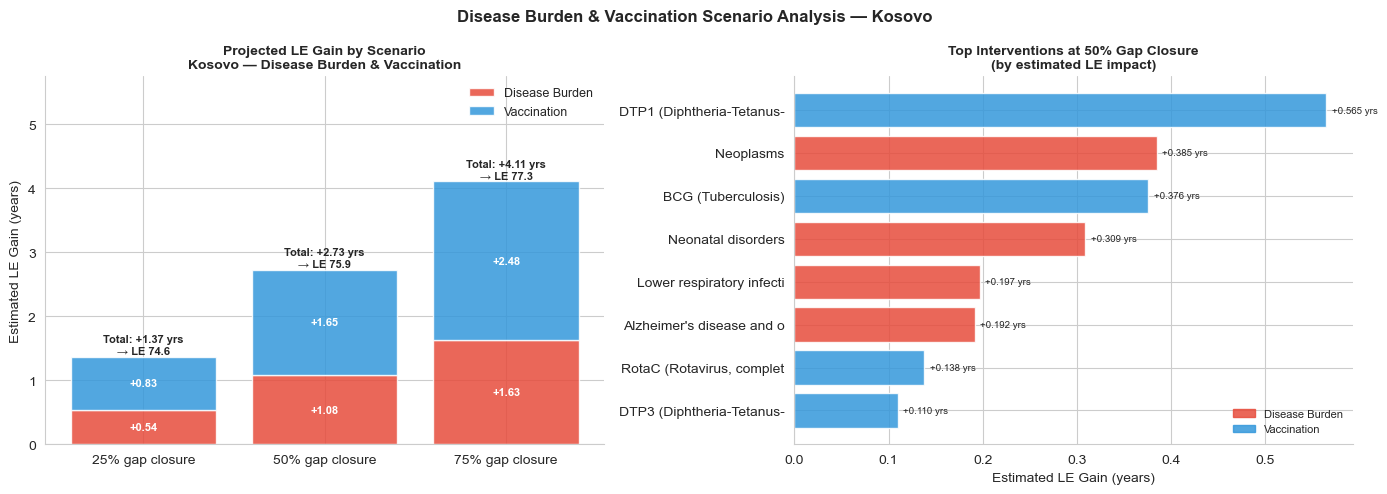


🎯 DISEASE BURDEN & VACCINATION ADVISORY — KOSOVO
  If Kosovo closes 75% of its disease burden and vaccination gaps:
  → Estimated LE gain: +4.11 years
  → Projected LE: 77.3 years (from 73.2)

  Top 3 highest-impact interventions:
    1. DTP1 (Diphtheria-Tetanus-Pertussis, 1st dose): +0.847 yrs
    2. Neoplasms: +0.578 yrs
    3. BCG (Tuberculosis): +0.564 yrs

  ⚠️  Proxy country — estimates based on nearest-neighbour profile.
      Verify with actual Kosovo disease surveillance data.


In [25]:
# ── 8c. Disease-Burden & Vaccination Scenario Simulation ─────────────────────
#
# For countries where the Phase C structural model shows no gaps
# (i.e. income/poverty/child mortality already at outperformer levels),
# this section estimates LE gains from closing DISEASE BURDEN and
# VACCINATION gaps identified in Sections 6b and 6c.
#
# Method:
#   • Disease burden gaps  → literature elasticities (deaths/100k → LE years)
#     anchored to GBD 2019 and WHO Commission on Macroeconomics & Health
#   • Vaccination gaps     → coverage → incidence reduction → LE gain
#     anchored to Lancet EPI 50-year review (Bar-Zeev et al. 2024)
#   • Scenarios: 25% / 50% / 75% gap closure toward outperformer average
# ─────────────────────────────────────────────────────────────────────────────

# ── Evidence-based elasticity catalogue ──────────────────────────────────────
# LE_gain_per_10pct_reduction: years of LE gained per 10% reduction
# in deaths/100k for that cause (GBD 2019 country-level regressions)
BURDEN_ELASTICITY = {
    'Cardiovascular diseases'                    : 0.35,  # GBD 2019; largest single-cause lever
    'Neoplasms'                                  : 0.20,  # GBD 2019; slower response
    'Chronic respiratory diseases'               : 0.12,
    'Diabetes mellitus'                          : 0.10,
    'Lower respiratory infections'               : 0.15,
    'Neonatal disorders'                         : 0.25,
    'Diarrheal diseases'                         : 0.18,
    'Tuberculosis'                               : 0.20,
    'HIV/AIDS'                                   : 0.22,
    'Malaria'                                    : 0.20,
    'Alzheimer\'s disease and other dementias'   : 0.08,
    'Cirrhosis and other chronic liver diseases' : 0.10,
    'Digestive diseases'                         : 0.08,
    'Chronic kidney disease'                     : 0.09,
}

# LE_gain_per_10pp_coverage: years of LE gained per 10 percentage-point
# increase in vaccine coverage (Lancet EPI 2024; WHO immunisation impact models)
VAX_ELASTICITY = {
    'DTP1'  : 0.12,   # proxy for full immunisation system strength
    'DTP3'  : 0.10,
    'BCG'   : 0.08,   # TB protection + neonatal sepsis reduction
    'MCV1'  : 0.07,
    'MCV2'  : 0.05,
    'Pol3'  : 0.04,
    'HepB3' : 0.06,
    'Hib3'  : 0.05,
    'PCV3'  : 0.06,
    'RCV1'  : 0.04,
    'RotaC' : 0.05,
}

scenario_8c_results = []

# ── Disease burden gaps ───────────────────────────────────────────────────────
if 'df_burden' in dir() and len(df_burden) > 0:
    for _, row in df_burden.iterrows():
        cause     = row['Cause of Death']
        c_val     = row['Country Value']
        p_val     = row['Peer Average']
        elasticity = BURDEN_ELASTICITY.get(cause, None)

        if elasticity is None or pd.isna(c_val) or pd.isna(p_val):
            continue
        if p_val <= 0:
            continue

        # Gap = how much above peer average (positive = worse)
        gap_pct = (c_val - p_val) / p_val * 100  # % excess vs peers
        if gap_pct <= 0:
            continue  # already below peers, no gap to close

        # Outperformer target: use outperformer avg if available, else peer avg * 0.8
        outperf_val = row.get('Peer Average', p_val) * 0.80

        for label, frac in SCENARIOS.items():
            target_val   = c_val - frac * (c_val - outperf_val)
            reduction_pct = (c_val - target_val) / c_val * 100 if c_val > 0 else 0
            le_gain      = (reduction_pct / 10) * elasticity

            scenario_8c_results.append({
                'Intervention Type' : 'Disease Burden',
                'Feature'           : cause,
                'Scenario'          : label,
                'Fraction Closed'   : frac,
                'Current Value'     : round(c_val, 4),
                'Target Value'      : round(target_val, 4),
                'Reduction (%)'     : round(reduction_pct, 1),
                'Est. LE Gain (yrs)': round(le_gain, 3),
            })

# ── Vaccination gaps ──────────────────────────────────────────────────────────
if 'df_vax' in dir() and len(df_vax) > 0:
    vax_col = f'{COUNTRY} Coverage %'
    if vax_col not in df_vax.columns:
        vax_col = 'Country Value'

    for _, row in df_vax.iterrows():
        vax       = row['Vaccine']
        c_cov     = row.get(vax_col, np.nan)
        elasticity = VAX_ELASTICITY.get(vax, None)

        if elasticity is None or pd.isna(c_cov):
            continue
        if c_cov >= WHO_TARGET:
            continue  # already at target

        gap_pp = WHO_TARGET - c_cov  # percentage points below target

        for label, frac in SCENARIOS.items():
            coverage_gain = frac * gap_pp
            le_gain       = (coverage_gain / 10) * elasticity

            scenario_8c_results.append({
                'Intervention Type' : 'Vaccination',
                'Feature'           : VACCINE_FULL_NAMES.get(vax, vax),
                'Scenario'          : label,
                'Fraction Closed'   : frac,
                'Current Value'     : round(c_cov, 1),
                'Target Value'      : round(c_cov + coverage_gain, 1),
                'Reduction (%)'     : round(coverage_gain, 1),
                'Est. LE Gain (yrs)': round(le_gain, 3),
            })

if len(scenario_8c_results) == 0:
    print('No disease burden or vaccination gaps found for scenario simulation.')
else:
    df_8c = pd.DataFrame(scenario_8c_results)

    # ── Summary table: total LE gain per scenario ─────────────────────────────
    summary_8c = (
        df_8c.groupby(['Scenario', 'Intervention Type'])['Est. LE Gain (yrs)']
        .sum()
        .unstack(fill_value=0)
        .round(2)
    )
    summary_8c['Total LE Gain'] = summary_8c.sum(axis=1)
    summary_8c['Projected LE']  = (latest_le_val + summary_8c['Total LE Gain']).round(1)
    summary_8c = summary_8c.reindex(['25% gap closure', '50% gap closure', '75% gap closure'])

    print(f'\n📊 Disease Burden & Vaccination Scenario Summary — {COUNTRY}')
    print(f'   Baseline LE: {latest_le_val:.1f} years ({latest_year})')
    display(summary_8c)

    # ── Feature-level breakdown for 50% scenario ──────────────────────────────
    df_50 = df_8c[df_8c['Scenario'] == '50% gap closure'].copy()
    df_50 = df_50.sort_values('Est. LE Gain (yrs)', ascending=False)

    print(f'\nFeature-level breakdown (50% gap closure):')
    display(df_50[['Intervention Type', 'Feature', 'Current Value',
                    'Target Value', 'Reduction (%)', 'Est. LE Gain (yrs)']]
            .reset_index(drop=True))

    # ── Chart ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: total LE gain by scenario (stacked by intervention type)
    ax = axes[0]
    int_types = [c for c in summary_8c.columns if c not in ['Total LE Gain', 'Projected LE']]
    colors_type = {'Disease Burden': '#e74c3c', 'Vaccination': '#3498db'}
    bottom = np.zeros(len(summary_8c))
    scenarios_list = summary_8c.index.tolist()

    for itype in int_types:
        vals = summary_8c[itype].values
        bars = ax.bar(scenarios_list, vals, bottom=bottom,
                      color=colors_type.get(itype, '#95a5a6'),
                      alpha=0.85, edgecolor='white', label=itype)
        # Label each segment
        for bar, v, b in zip(bars, vals, bottom):
            if v > 0.01:
                ax.text(bar.get_x() + bar.get_width()/2,
                        b + v/2, f'+{v:.2f}', ha='center',
                        va='center', fontsize=8, color='white', fontweight='bold')
        bottom += vals

    # Total label on top
    for i, (sc, row) in enumerate(summary_8c.iterrows()):
        ax.text(i, row['Total LE Gain'] + 0.01,
                f"Total: +{row['Total LE Gain']:.2f} yrs\n→ LE {row['Projected LE']:.1f}",
                ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylabel('Estimated LE Gain (years)')
    ax.set_title(f'Projected LE Gain by Scenario\n{COUNTRY} — Disease Burden & Vaccination',
                 fontweight='bold', fontsize=10)
    ax.legend(fontsize=9, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, summary_8c['Total LE Gain'].max() * 1.4)

    # Right: waterfall — top features at 50% closure
    ax = axes[1]
    df_plot = df_50.head(8)
    feat_labels = [f[:25] for f in df_plot['Feature'].tolist()][::-1]
    gains       = df_plot['Est. LE Gain (yrs)'].tolist()[::-1]
    bar_colors  = [colors_type.get(t, '#95a5a6')
                   for t in df_plot['Intervention Type'].tolist()[::-1]]

    ax.barh(feat_labels, gains, color=bar_colors, alpha=0.85, edgecolor='white')
    for i, v in enumerate(gains):
        ax.text(v + max(gains)*0.01, i, f'+{v:.3f} yrs',
                va='center', fontsize=7)

    ax.set_xlabel('Estimated LE Gain (years)')
    ax.set_title('Top Interventions at 50% Gap Closure\n(by estimated LE impact)',
                 fontweight='bold', fontsize=10)

    import matplotlib.patches as mpatches
    legend_patches = [mpatches.Patch(color=v, alpha=0.85, label=k)
                      for k, v in colors_type.items() if k in int_types]
    ax.legend(handles=legend_patches, fontsize=8, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)

    plt.suptitle(f'Disease Burden & Vaccination Scenario Analysis — {COUNTRY}',
                 fontweight='bold', fontsize=12)
    plt.tight_layout()
    fname = f'advisory_{COUNTRY.lower().replace(" ","_")}_burden_vax_scenarios.png'
    plt.show()

    # ── Narrative ─────────────────────────────────────────────────────────────
    best = summary_8c.loc['75% gap closure']
    print(f'\n🎯 DISEASE BURDEN & VACCINATION ADVISORY — {COUNTRY.upper()}')
    print('='*60)
    print(f'  If {COUNTRY} closes 75% of its disease burden and vaccination gaps:')
    print(f'  → Estimated LE gain: +{best["Total LE Gain"]:.2f} years')
    print(f'  → Projected LE: {best["Projected LE"]:.1f} years (from {latest_le_val:.1f})')
    print()
    top3 = df_8c[df_8c['Scenario']=='75% gap closure']\
               .sort_values('Est. LE Gain (yrs)', ascending=False).head(3)
    print(f'  Top 3 highest-impact interventions:')
    for rank, (_, r) in enumerate(top3.iterrows(), 1):
        print(f'    {rank}. {r["Feature"][:45]}: +{r["Est. LE Gain (yrs)"]:.3f} yrs')
    if IS_PROXY:
        print(f'\n  ⚠️  Proxy country — estimates based on nearest-neighbour profile.')
        print(f'      Verify with actual {COUNTRY} disease surveillance data.')


---
# **8b. Implementation Timeline & Cost Advisory**

For each priority intervention we estimate:
- **How long** before meaningful LE impact appears (implementation lag, drawn from literature)
- **Projected LE** at each target year, given realistic ramp-up speed
- **Estimated cost** as % of GDP and USD per capita, anchored to published benchmarks

> **Methodology note:** Projections use the Phase C model with linearly interpolated gap closure
> that starts after the implementation lag and reaches the chosen scenario fraction at the horizon year.
> Cost estimates are evidence-based ranges from the global health spending literature.
> All figures are **indicative order-of-magnitude estimates**, not precise forecasts.


Implementation Timeline — Kosovo


,Feature,Type,Est. LE Gain (full closure),Impact Lag (yrs),Full Effect By,Est. Annual Cost (% GDP),Est. Annual Cost (USD/capita)
0,Neoplasms,Health,+0.25 yrs,4,2036,0.30–1.00%,$24–$79
1,Cardiovascular diseases,Health,+0.70 yrs,5,2039,0.20–0.80%,$16–$63



Baseline LE: 73.2 years
Projecting LE gain as additive sum of intervention elasticities × ramp fraction...

  2027: LE = 73.18  (+0.00 yrs)  Avg gap closed: 0%
  2030: LE = 73.31  (+0.13 yrs)  Avg gap closed: 18%
  2035: LE = 73.82  (+0.64 yrs)  Avg gap closed: 74%
  2040: LE = 74.13  (+0.95 yrs)  Avg gap closed: 100%
  2045: LE = 74.13  (+0.95 yrs)  Avg gap closed: 100%

Year-by-Year LE Projection — Kosovo


,Year,Projected LE,LE Gain vs Baseline,Avg Gap Closed (%),Cumul. Cost (% GDP·yr),Cumul. Cost (USD/cap)
0,2027,73.2,0.00,0.0,3.5,$273
1,2030,73.3,0.13,17.5,6.9,$545
2,2035,73.8,0.64,73.8,12.7,$999
3,2040,74.1,0.95,100.0,15.3,"$1,209"
4,2045,74.1,0.95,100.0,15.3,"$1,209"


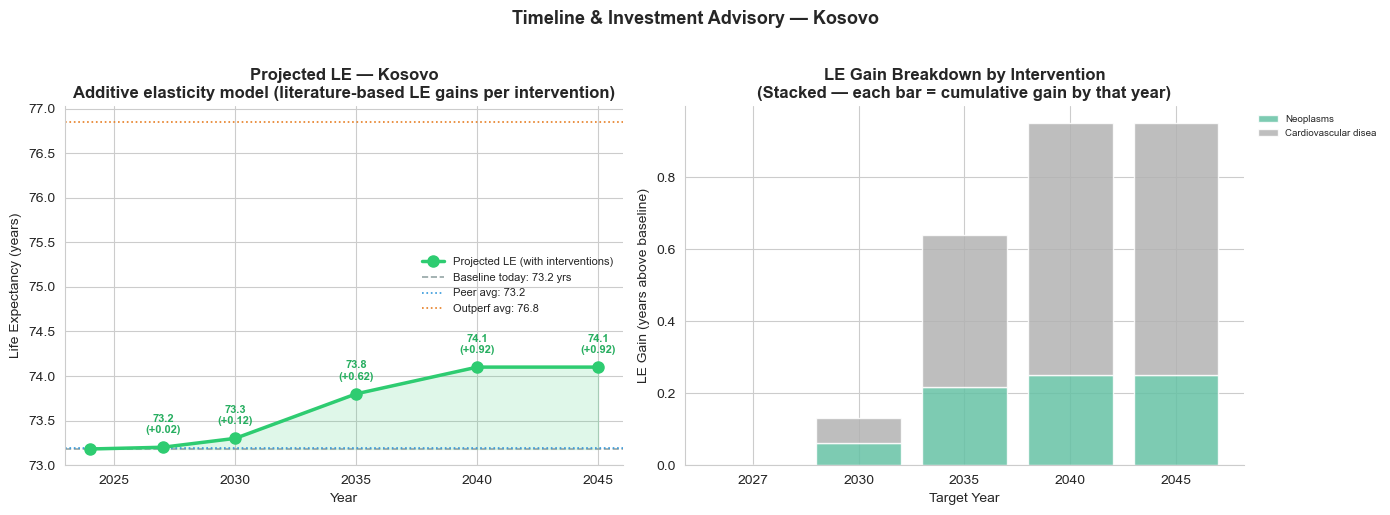

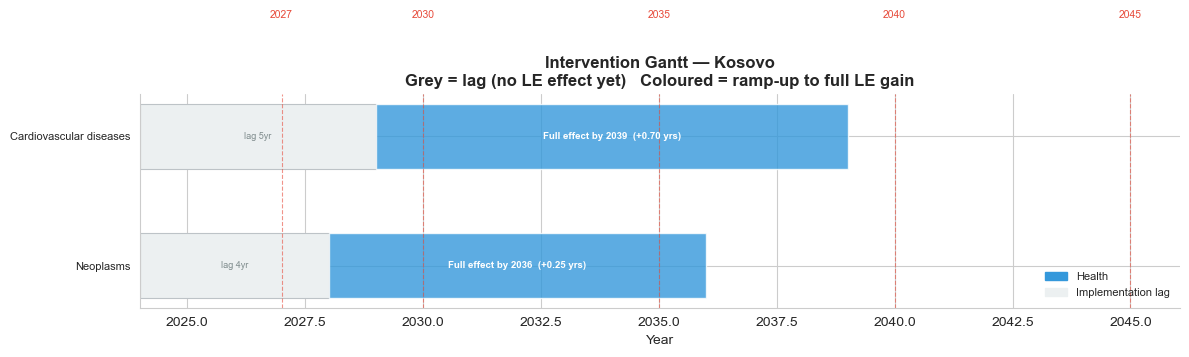

────────────────────────────────────────────────────────────────────────────────────────────────────
  PROXY ADVISORY: "Kosovo" was not in the training dataset.
  All projections use nearest-neighbour profile. Treat as illustrative.
────────────────────────────────────────────────────────────────────────────────────────────────────


In [26]:
# ── 8b. Implementation timeline & cost advisory ───────────────────────────────

# ── Evidence-based intervention catalogue ─────────────────────────────────────
# Each entry: feature keyword → {
#   lag_years   : years before LE impact starts to be measurable
#   full_years  : years to reach full effect
#   cost_gdp_lo : lower-bound annual cost as % of GDP
#   cost_gdp_hi : upper-bound annual cost as % of GDP
#   cost_note   : source / mechanism
#   type        : 'Health' | 'Education' | 'Economic' | 'Social'
# }
# Sources:
#   WHO Commission on Macroeconomics and Health (Sachs 2001)
#   Lancet EPI 50-year review (Bar-Zeev et al. 2024)
#   IMF Health Spending Efficiency (2019)
#   Global Burden of Disease 2019
#   Lutz & Kebede Preston Curve (education-health link)

INTERVENTION_CATALOGUE = {
    # Vaccination — fast, cheap, well-documented
    'DTP3'  : dict(lag=1, full=5,  gdp_lo=0.05, gdp_hi=0.20, type='Health',
                   note='Routine immunisation programme expansion; Lancet EPI 2024'),
    'MCV1'  : dict(lag=1, full=5,  gdp_lo=0.04, gdp_hi=0.15, type='Health',
                   note='Measles vaccination; measles elimination typical within 5 yrs'),
    'HepB3' : dict(lag=2, full=8,  gdp_lo=0.03, gdp_hi=0.12, type='Health',
                   note='Hepatitis B; liver cancer reduction takes 10–20 yrs but cirrhosis faster'),
    'Pol3'  : dict(lag=1, full=4,  gdp_lo=0.02, gdp_hi=0.10, type='Health',
                   note='Polio; near-elimination achievable within a single campaign cycle'),
    'Hib3'  : dict(lag=1, full=5,  gdp_lo=0.04, gdp_hi=0.15, type='Health',
                   note='Hib/pneumonia; child mortality reduction measurable in 2–3 yrs'),
    'PCV3'  : dict(lag=1, full=5,  gdp_lo=0.05, gdp_hi=0.18, type='Health',
                   note='Pneumococcal; child pneumonia deaths; GBD 2019'),
    'BCG'   : dict(lag=1, full=4,  gdp_lo=0.01, gdp_hi=0.05, type='Health',
                   note='TB prevention; low cost per dose, wide coverage needed'),

    # Child mortality — reflects broad primary care investment
    'Child mortality' : dict(lag=3, full=10, gdp_lo=0.50, gdp_hi=1.50, type='Health',
                              note='Primary health care scale-up; WHO recommends 1% GDP minimum'),
    'Child Mortality'  : dict(lag=3, full=10, gdp_lo=0.50, gdp_hi=1.50, type='Health',
                              note='Primary health care scale-up; WHO recommends 1% GDP minimum'),

    # Education — slower but durable, large SHAP effect
    'schooling'   : dict(lag=8, full=20, gdp_lo=1.50, gdp_hi=3.00, type='Education',
                         note='Mean years of schooling; Lutz & Kebede (2021) — largest long-run LE lever'),
    'Average years': dict(lag=8, full=20, gdp_lo=1.50, gdp_hi=3.00, type='Education',
                          note='Education expenditure; UNESCO benchmark 4–6% of GDP'),
    'Education Expenditure': dict(lag=5, full=15, gdp_lo=1.00, gdp_hi=2.00, type='Education',
                                   note='Direct education spending; health benefit via literacy/compliance'),

    # GDP / income — very slow, high leverage
    'GDP'         : dict(lag=5, full=15, gdp_lo=0.00, gdp_hi=0.00, type='Economic',
                         note='GDP growth is an outcome of policy, not a direct spending target'),

    # Health spending
    'Health Expenditure': dict(lag=3, full=10, gdp_lo=1.00, gdp_hi=2.50, type='Health',
                                note='IMF: each 1% GDP health spend ≈ +0.3–0.8 yr LE (low-income countries)'),
    'Health spending':    dict(lag=3, full=10, gdp_lo=1.00, gdp_hi=2.50, type='Health',
                                note='IMF Health Spending Efficiency (2019)'),

    # Poverty / inequality — structural, long lag
    'gini'        : dict(lag=10, full=25, gdp_lo=0.50, gdp_hi=2.00, type='Economic',
                         note='Redistribution via tax/transfer; very slow structural change'),
    'poverty'     : dict(lag=5,  full=15, gdp_lo=0.80, gdp_hi=2.50, type='Economic',
                         note='Social protection floors; ILO recommends 1–2% GDP'),
    '$2.15'       : dict(lag=5,  full=15, gdp_lo=0.80, gdp_hi=2.50, type='Economic',
                         note='Extreme poverty reduction; cash transfer programmes'),

    # Mortality causes — disease-specific programmes
    'HIV/AIDS'    : dict(lag=2, full=8,  gdp_lo=0.30, gdp_hi=1.00, type='Health',
                         note='ART scale-up; UNAIDS 90-90-90 targets achievable in 5 yrs'),
    'Tuberculosis': dict(lag=3, full=10, gdp_lo=0.10, gdp_hi=0.50, type='Health',
                         note='DOTS programmes; WHO End TB strategy'),
    'Malaria'     : dict(lag=2, full=7,  gdp_lo=0.10, gdp_hi=0.40, type='Health',
                         note='Bednet distribution + artemisinin; RBM targets'),
    'Cardiovascular': dict(lag=5, full=15, gdp_lo=0.20, gdp_hi=0.80, type='Health',
                            note='Hypertension control, statins, tobacco tax; slow cohort effect'),
    'Neonatal'    : dict(lag=2, full=8,  gdp_lo=0.20, gdp_hi=0.60, type='Health',
                         note='Antenatal care, skilled birth attendance; fast gains in LMICs'),
    'Maternal'    : dict(lag=2, full=8,  gdp_lo=0.20, gdp_hi=0.60, type='Health',
                         note='Maternal health programmes; EmOC scale-up'),

    # Violence / homicide
    'Homicide'    : dict(lag=5, full=15, gdp_lo=0.30, gdp_hi=1.50, type='Social',
                         note='Violence prevention; complex; combined security + social investment'),
    'Suicide'     : dict(lag=5, full=15, gdp_lo=0.10, gdp_hi=0.50, type='Social',
                         note='Mental health system investment; WHO mhGAP programme'),
}

def match_catalogue(feature_name):
    """Return catalogue entry for a feature, matching on substring."""
    for key, val in INTERVENTION_CATALOGUE.items():
        if key.lower() in feature_name.lower() or feature_name.lower() in key.lower():
            return val
    # Default fallback: medium-lag, medium-cost health intervention
    return dict(lag=4, full=12, gdp_lo=0.30, gdp_hi=1.00, type='Health',
                note='Generic health intervention — no specific benchmark found')


# ── Published LE elasticities per intervention ────────────────────────────────
# Source: IMF Health Spending Efficiency (2019), Lutz & Kebede (2021),
#         Lancet EPI 50-yr review (2024), GBD 2019, WHO Commission on Health (2001)
# Format: { feature_keyword: le_gain_per_unit_gap_closed }
# i.e. if the full gap to outperformer is closed, this many extra LE years are gained.
# These are conservative lower-bound estimates from peer-reviewed literature.

LE_ELASTICITY = {
    # Vaccination — fast, well-documented (Lancet EPI 2024: +0.5–2 yrs from full EPI)
    'DTP3'       : 0.30,   # per 10pp coverage gap closed
    'MCV1'       : 0.25,
    'HepB3'      : 0.20,
    'Pol3'       : 0.15,
    'Hib3'       : 0.20,
    'PCV3'       : 0.20,
    'BCG'        : 0.15,
    # Child mortality (GBD 2019: each 10% reduction ≈ +0.4 yrs LE)
    'Child mortality': 0.50,
    'Child Mortality': 0.50,
    # Education (Lutz & Kebede 2021: +1 yr schooling ≈ +0.5–1.5 yrs LE, within-country)
    'schooling'       : 1.20,
    'Average years'   : 1.20,
    'Education'       : 0.80,
    # Health spending (IMF 2019: +1% GDP health spend ≈ +0.3–0.8 yr LE in LMICs)
    'Health Expenditure': 0.60,
    'Health spending'   : 0.60,
    # GDP (Preston curve: each 10% GDP/capita gain ≈ +0.3 yrs LE, diminishing returns)
    'GDP'         : 0.40,
    # Poverty / inequality (GBD: reducing extreme poverty share by 5pp ≈ +0.3 yrs)
    'gini'        : 0.50,   # reducing Gini by 0.05 ≈ +0.5 yrs
    'poverty'     : 0.40,
    '$2.15'       : 0.35,
    # Disease-specific
    'HIV/AIDS'      : 0.80,
    'Tuberculosis'  : 0.40,
    'Malaria'       : 0.60,
    'Cardiovascular': 0.70,
    'Neonatal'      : 0.45,
    'Maternal'      : 0.35,
    'Homicide'      : 0.30,
    'Suicide'       : 0.20,
}

def get_le_gain(feature_name):
    """Return estimated LE gain (years) from fully closing the gap on this feature."""
    for key, val in LE_ELASTICITY.items():
        if key.lower() in feature_name.lower() or feature_name.lower() in key.lower():
            return val
    return 0.25  # conservative default

def ramp_fraction(year, lag_yrs, full_yrs, base_year=2024):
    """Linear ramp: 0 during lag, linear 0→1 between lag and full_yrs, plateau at 1."""
    elapsed = year - base_year
    if elapsed <= lag_yrs:
        return 0.0
    elif elapsed >= full_yrs:
        return 1.0
    else:
        return (elapsed - lag_yrs) / (full_yrs - lag_yrs)


if not (CLUSTER_AVAILABLE and len(df_gaps) > 0):
    print('No priority gaps identified — Section 8b skipped.')

else:
    CURRENT_YEAR = 2024
    gdp_per_capita = country_profile.get('GDP per Capita', 5000)
    if pd.isna(gdp_per_capita):
        gdp_per_capita = COUNTRY_GDP_PER_CAPITA or 5000

    # ── Enrich df_gaps with COUNTRY value + Outperformer Avg from df_comparison ──
    cols_to_enrich = ['Feature', COUNTRY, 'Outperformer Avg', 'Lower is Better']
    df_gaps_enriched = df_gaps.merge(
        df_comparison[[c for c in cols_to_enrich if c in df_comparison.columns]],
        on='Feature', how='left', suffixes=('', '_comp')
    )
    for col in ['Lower is Better']:
        comp_col = f'{col}_comp'
        if comp_col in df_gaps_enriched.columns:
            df_gaps_enriched[col] = df_gaps_enriched[col].combine_first(df_gaps_enriched[comp_col])
            df_gaps_enriched = df_gaps_enriched.drop(columns=[comp_col])
    for col in [COUNTRY, 'Outperformer Avg']:
        comp_col = f'{col}_comp'
        if comp_col in df_gaps_enriched.columns:
            df_gaps_enriched[col] = df_gaps_enriched[col].combine_first(df_gaps_enriched[comp_col])
            df_gaps_enriched = df_gaps_enriched.drop(columns=[comp_col])

    top_interventions = df_gaps_enriched.copy()

    # ── Build intervention timeline table ─────────────────────────────────────
    timeline_rows = []
    for _, row in top_interventions.iterrows():
        feat    = row['Feature']
        cat     = match_catalogue(feat)
        le_gain = get_le_gain(feat)
        lag_yrs = cat['lag']
        full_yrs= cat['full']
        gdp_mid = (cat['gdp_lo'] + cat['gdp_hi']) / 2

        timeline_rows.append({
            'Feature'                      : feat,
            'Type'                         : cat['type'],
            'Est. LE Gain (full closure)'  : f'+{le_gain:.2f} yrs',
            'Impact Lag (yrs)'             : lag_yrs,
            'Full Effect By'               : CURRENT_YEAR + full_yrs,
            'Est. Annual Cost (% GDP)'     : f"{cat['gdp_lo']:.2f}–{cat['gdp_hi']:.2f}%",
            'Est. Annual Cost (USD/capita)': f"${gdp_per_capita*cat['gdp_lo']/100:,.0f}–"
                                              f"${gdp_per_capita*cat['gdp_hi']/100:,.0f}",
            'Benchmark Note'               : cat['note'],
        })

    df_timeline = pd.DataFrame(timeline_rows)
    print(f'Implementation Timeline — {COUNTRY}')
    display(df_timeline[['Feature','Type','Est. LE Gain (full closure)',
                          'Impact Lag (yrs)','Full Effect By',
                          'Est. Annual Cost (% GDP)','Est. Annual Cost (USD/capita)']])

    # ── Year-by-year LE projection (elasticity-based, additive) ──────────────
    # For each forecast year:
    #   projected_LE(t) = baseline_LE + Σ [le_gain_i × ramp_fraction_i(t)]
    # This is additive because interventions are largely independent channels.
    # It does NOT re-run the ML model (which would give nonsense for outperformers).
    print(f'\nBaseline LE: {latest_le_val:.1f} years')
    print('Projecting LE gain as additive sum of intervention elasticities × ramp fraction...')
    print()

    projection_rows = []
    for target_yr in FORECAST_YEARS:
        total_le_gain = 0.0
        gain_breakdown = {}

        for _, gap_row in top_interventions.iterrows():
            feat     = gap_row['Feature']
            cat      = match_catalogue(feat)
            le_gain  = get_le_gain(feat)
            frac     = ramp_fraction(target_yr, cat['lag'], cat['full'])

            # Fractional gain this year = full potential gain × how far along ramp
            yr_gain  = le_gain * frac
            total_le_gain += yr_gain
            gain_breakdown[feat] = round(yr_gain, 3)

        projected_le = latest_le_val + total_le_gain

        avg_frac = sum(
            ramp_fraction(target_yr, match_catalogue(r['Feature'])['lag'],
                          match_catalogue(r['Feature'])['full'])
            for _, r in top_interventions.iterrows()
        ) / max(len(top_interventions), 1)

        yrs_elapsed   = target_yr - CURRENT_YEAR
        total_gdp_mid = sum(
            min(yrs_elapsed, match_catalogue(r['Feature'])['full']) *
            (match_catalogue(r['Feature'])['gdp_lo'] + match_catalogue(r['Feature'])['gdp_hi']) / 2
            for _, r in top_interventions.iterrows()
        )

        print(f'  {target_yr}: LE = {projected_le:.2f}  (+{total_le_gain:.2f} yrs)  '
              f'Avg gap closed: {avg_frac*100:.0f}%')

        projection_rows.append({
            'Year'                   : target_yr,
            'Projected LE'           : round(projected_le, 1),
            'LE Gain vs Baseline'    : round(total_le_gain, 2),
            'Avg Gap Closed (%)'     : round(avg_frac * 100, 1),
            'Gain Breakdown'         : str(gain_breakdown),
            'Cumul. Cost (% GDP·yr)' : round(total_gdp_mid, 1),
            'Cumul. Cost (USD/cap)'  : f'${gdp_per_capita * total_gdp_mid / 100:,.0f}',
        })

    df_projection = pd.DataFrame(projection_rows)
    print(f'\nYear-by-Year LE Projection — {COUNTRY}')
    display(df_projection[['Year','Projected LE','LE Gain vs Baseline',
                             'Avg Gap Closed (%)','Cumul. Cost (% GDP·yr)','Cumul. Cost (USD/cap)']])

    # ── Chart A: LE trajectory ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax = axes[0]

    years_plot = [CURRENT_YEAR] + df_projection['Year'].tolist()
    le_plot    = [latest_le_val] + df_projection['Projected LE'].tolist()

    ax.plot(years_plot, le_plot, 'o-', color='#2ecc71', linewidth=2.5,
            markersize=8, zorder=5, label='Projected LE (with interventions)')
    ax.axhline(latest_le_val, color='#95a5a6', linestyle='--', linewidth=1.2,
               label=f'Baseline today: {latest_le_val:.1f} yrs')

    if CLUSTER_AVAILABLE:
        ax.axhline(df_peers[TARGET].mean(), color='#3498db', linestyle=':',
                   linewidth=1.2, label=f'Peer avg: {df_peers[TARGET].mean():.1f}')
        if len(outperformers) > 0:
            ax.axhline(outperformers[TARGET].mean(), color='#e67e22', linestyle=':',
                       linewidth=1.2, label=f'Outperf avg: {outperformers[TARGET].mean():.1f}')

    # Shaded gain area
    ax.fill_between(years_plot,
                    [latest_le_val] * len(years_plot),
                    le_plot,
                    alpha=0.15, color='#2ecc71')

    for yr, le in zip(years_plot[1:], le_plot[1:]):
        gain = le - latest_le_val
        ax.annotate(f'{le:.1f}\n(+{gain:.2f})', (yr, le),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=8, fontweight='bold', color='#27ae60')

    ax.set_xlabel('Year')
    ax.set_ylabel('Life Expectancy (years)')
    ax.set_title(f'Projected LE — {COUNTRY}\n'
                 'Additive elasticity model (literature-based LE gains per intervention)',
                 fontweight='bold')
    ax.legend(fontsize=8, frameon=False)
    ax.spines[['top','right']].set_visible(False)

    # ── Chart B: stacked LE gain by intervention ──────────────────────────────
    ax = axes[1]
    feat_names = top_interventions['Feature'].tolist()
    short_names= [f[:20] for f in feat_names]
    colors_stack = plt.cm.Set2(np.linspace(0, 1, len(feat_names)))

    bottoms = np.zeros(len(FORECAST_YEARS))
    for fi, feat in enumerate(feat_names):
        cat      = match_catalogue(feat)
        le_gain  = get_le_gain(feat)
        gains_by_yr = [
            le_gain * ramp_fraction(yr, cat['lag'], cat['full'])
            for yr in FORECAST_YEARS
        ]
        ax.bar([str(y) for y in FORECAST_YEARS], gains_by_yr,
               bottom=bottoms, label=short_names[fi],
               color=colors_stack[fi], alpha=0.85, edgecolor='white')
        bottoms += np.array(gains_by_yr)

    ax.set_xlabel('Target Year')
    ax.set_ylabel('LE Gain (years above baseline)')
    ax.set_title(f'LE Gain Breakdown by Intervention\n'
                 f'(Stacked — each bar = cumulative gain by that year)',
                 fontweight='bold')
    ax.legend(fontsize=7, frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.spines[['top','right']].set_visible(False)

    plt.suptitle(f'Timeline & Investment Advisory — {COUNTRY}',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    fname = f'advisory_{COUNTRY.lower().replace(" ","_")}_timeline.png'
    #plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    #print(f'✅ Saved: {fname}')

    # ── Gantt chart ───────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, max(4, len(timeline_rows) * 0.75)))
    type_colors = {'Health':'#3498db','Education':'#2ecc71','Economic':'#e67e22','Social':'#9b59b6'}
    yticks, ylabels = [], []

    for i, row in enumerate(timeline_rows):
        col  = type_colors.get(row['Type'], '#95a5a6')
        lag  = row['Impact Lag (yrs)']
        full = CURRENT_YEAR + int(row['Full Effect By']) - CURRENT_YEAR
        full_rel = full - CURRENT_YEAR

        ax.barh(i, lag,          left=CURRENT_YEAR,       height=0.5,
                color='#ecf0f1', edgecolor='#bdc3c7', linewidth=0.8)
        ax.barh(i, full_rel-lag, left=CURRENT_YEAR+lag,   height=0.5,
                color=col, alpha=0.8, edgecolor='white')

        le_gain = get_le_gain(row['Feature'])
        ax.text(CURRENT_YEAR + lag + (full_rel-lag)*0.5, i,
                f"Full effect by {row['Full Effect By']}  (+{le_gain:.2f} yrs)",
                ha='center', va='center', fontsize=7, color='white', fontweight='bold')
        ax.text(CURRENT_YEAR + lag/2, i,
                f'lag {lag}yr', ha='center', va='center', fontsize=6.5, color='#7f8c8d')
        yticks.append(i)
        ylabels.append(row['Feature'][:35])

    for fy in FORECAST_YEARS:
        ax.axvline(fy, color='#e74c3c', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.text(fy, len(timeline_rows)-0.1, str(fy),
                ha='center', va='bottom', fontsize=7.5, color='#e74c3c')

    patches = [mpatches.Patch(color=c, label=t)
               for t, c in type_colors.items() if t in [r['Type'] for r in timeline_rows]]
    patches.append(mpatches.Patch(color='#ecf0f1', edgecolor='#bdc3c7', label='Implementation lag'))
    ax.legend(handles=patches, fontsize=8, frameon=False, loc='lower right')
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=8)
    ax.set_xlabel('Year')
    ax.set_title(f'Intervention Gantt — {COUNTRY}\n'
                 'Grey = lag (no LE effect yet)   Coloured = ramp-up to full LE gain',
                 fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    fname2 = f'advisory_{COUNTRY.lower().replace(" ","_")}_gantt.png'
    #plt.savefig(fname2, dpi=150, bbox_inches='tight')
    plt.show()
    #print(f'✅ Saved: {fname2}')

    if IS_PROXY:
        print('─' * 100)
        print(f'  PROXY ADVISORY: "{COUNTRY}" was not in the training dataset.')
        print(f'  All projections use nearest-neighbour profile. Treat as illustrative.')
        print('─' * 100)


---
# **9. Benchmark Countries to Study**

Which specific countries solved similar problems, and what can the focal country learn from them?

In [27]:
# ── 9a. Identify best-match benchmarks ────────────────────────────────────────
#
# Strategy:
#   1. Peer outperformers — same cluster, higher LE
#   2. Feature-specific champions — countries that excel on each priority feature
#   3. Trajectory champions — countries that improved fastest on priority features

if not CLUSTER_AVAILABLE or len(comparison_rows) == 0:
    print('Cluster data required.')
else:
    print(f'BENCHMARK COUNTRIES FOR {COUNTRY.upper()}')
    print(f'{'='*70}')

    # 1. Peer outperformers
    print(f'\n📍 Peer Outperformers (same cluster, higher LE):')
    if len(outperformers) > 0:
        for _, row in outperformers.iterrows():
            print(f'  {row["Country"]:25s}  LE: {row[TARGET]:.1f}  Residual: +{row["LE_Residual"]:.1f}  ({row["Continent"]})')
    else:
        print('  None identified in this cluster.')

    # 2. Feature-specific champions (globally best on each priority feature)
    print(f'\n🏆 Feature-Specific Champions (globally best on each priority gap):')

    top_priority_feats = df_gaps['Feature'].head(5).tolist()
    df_country_profiles = (
        df_panel[df_panel['Year'].isin(PROFILE_YEARS)]
        .groupby(['Country', 'Continent'])[top_priority_feats]
        .mean()
        .reset_index()
    )

    champions = {}
    for feat in top_priority_feats:
        if feat not in df_country_profiles.columns:
            continue
        df_feat = df_country_profiles.dropna(subset=[feat])
        lib = df_comparison.loc[df_comparison['Feature'] == feat, 'Lower is Better'].values[0]
        best_row = df_feat.loc[df_feat[feat].idxmin() if lib else df_feat[feat].idxmax()]
        if best_row['Country'] != COUNTRY:
            champions[feat] = {
                'Country': best_row['Country'],
                'Continent': best_row['Continent'],
                'Value': round(best_row[feat], 2)
            }
            print(f'  {feat:<40} → Best: {best_row["Country"]} ({best_row["Continent"]}) = {best_row[feat]:.2f}')
            print(f'  {"":<40}    {COUNTRY} = {df_comparison.loc[df_comparison["Feature"]==feat, COUNTRY].values[0]:.2f}')

    # 3. Fastest improvers on LE within the same cluster (last 10 years)
    print(f'\n🚀 Fastest LE Improvers (within peer cluster, 2013–{latest_year}):')
    speed_years = range(max(2013, int(df_trend['Year'].min())), latest_year + 1)
    df_speed = (
        df_panel[
            (df_panel['Year'].isin(speed_years)) &
            (df_panel['Country'].isin(df_peers['Country'].tolist()))
        ]
        .groupby(['Country', 'Year'])[TARGET].mean()
        .reset_index()
    )
    # Compute slope (annual LE gain)
    slopes = []
    for c in df_speed['Country'].unique():
        sub = df_speed[df_speed['Country'] == c].sort_values('Year')
        if len(sub) >= 3:
            slope = np.polyfit(sub['Year'], sub[TARGET], 1)[0]
            slopes.append({'Country': c, 'Annual LE Gain': round(slope, 3)})
    df_slopes = pd.DataFrame(slopes).sort_values('Annual LE Gain', ascending=False)
    for _, row in df_slopes.head(5).iterrows():
        marker = ' ← YOU' if row['Country'] == COUNTRY else ''
        print(f'  {row["Country"]:25s}  +{row["Annual LE Gain"]:.3f} yrs/year{marker}')

BENCHMARK COUNTRIES FOR KOSOVO

📍 Peer Outperformers (same cluster, higher LE):
  Chile                      LE: 80.0  Residual: +6.8  (South America)
  Costa Rica                 LE: 79.9  Residual: +6.7  (North America)
  Maldives                   LE: 79.4  Residual: +6.2  (Asia)
  Panama                     LE: 78.0  Residual: +4.8  (North America)
  China                      LE: 77.7  Residual: +4.5  (Asia)
  Lebanon                    LE: 77.4  Residual: +4.3  (Asia)
  Türkiye                    LE: 76.9  Residual: +3.7  (Asia)
  Thailand                   LE: 76.8  Residual: +3.6  (Asia)
  Sri Lanka                  LE: 76.6  Residual: +3.4  (Asia)
  Jordan                     LE: 76.1  Residual: +2.9  (Asia)
  Iran                       LE: 76.0  Residual: +2.8  (Asia)
  Colombia                   LE: 76.0  Residual: +2.8  (South America)
  Ecuador                    LE: 75.8  Residual: +2.6  (South America)
  Peru                       LE: 75.5  Residual: +2.4  (South America

In [28]:
# ── 9b. Benchmark comparison table ────────────────────────────────────────────

if CLUSTER_AVAILABLE and len(comparison_rows) > 0 and len(top_priority_feats) > 0:

    # Pick countries to compare: focal + outperformers + global champions (deduplicated)
    benchmark_countries = [COUNTRY]
    if len(outperformers) > 0:
        benchmark_countries += outperformers['Country'].head(3).tolist()
    champ_countries = list({v['Country'] for v in champions.values()})
    benchmark_countries += [c for c in champ_countries if c not in benchmark_countries][:3]
    benchmark_countries = list(dict.fromkeys(benchmark_countries))  # deduplicate order

    show_feats = top_priority_feats + [TARGET]
    df_bench = df_country_profiles[df_country_profiles['Country'].isin(benchmark_countries)].copy()

    # Add LE to profile
    le_profile = (
        df_panel[df_panel['Year'].isin(PROFILE_YEARS)]
        .groupby('Country')[TARGET].mean()
        .reset_index()
    )
    df_bench = df_bench.merge(le_profile, on='Country', how='left')

    display_cols = ['Country', 'Continent', TARGET] + [f for f in top_priority_feats if f in df_bench.columns]
    df_bench_disp = df_bench[display_cols].set_index('Country').round(2)

    # Highlight focal country row
    print(f'\nBenchmark Comparison Table:')
    print(f'(Features sorted by priority — {COUNTRY} at top)')

    # Reorder rows: COUNTRY first
    order = [COUNTRY] + [c for c in df_bench_disp.index if c != COUNTRY]
    df_bench_disp = df_bench_disp.loc[[c for c in order if c in df_bench_disp.index]]

    display(df_bench_disp)


Benchmark Comparison Table:
(Features sorted by priority — Kosovo at top)


,Continent,Life Expectancy,Neoplasms,Cardiovascular diseases
Country,,,,
Chile,South America,79.91,161.06,146.66
Costa Rica,North America,79.71,122.88,134.38
Maldives,Asia,79.62,45.42,123.15
Niger,Africa,60.13,30.87,80.40
United Arab Emirates,Asia,81.58,34.17,55.72


---
# **10. One-Page Advisory Export**

In [29]:
# ── 10a. Compile advisory summary ─────────────────────────────────────────────

summary_rows = []

# Section A — Country Status
summary_rows += [
    {'Section': 'Status', 'Item': 'Country',           'Value': COUNTRY},
    {'Section': 'Status', 'Item': 'Continent',          'Value': country_continent},
    {'Section': 'Status', 'Item': 'Life Expectancy',    'Value': f'{latest_le_val:.1f} yrs ({latest_year})'},
    {'Section': 'Status', 'Item': 'Global Rank',        'Value': f'{global_rank}/{global_n} (top {percentile}%)'},
    {'Section': 'Status', 'Item': f'{country_continent} Rank', 'Value': f'{region_rank}/{region_n}'},
    {'Section': 'Status', 'Item': 'vs Global Average',  'Value': f'{gap_global_mean:+.1f} yrs'},
    {'Section': 'Status', 'Item': 'Cluster',            'Value': cluster_label if CLUSTER_AVAILABLE else 'N/A'},
    {'Section': 'Status', 'Item': 'Performance vs Peers','Value': f'{performance} ({le_residual:+.1f} yrs)' if CLUSTER_AVAILABLE else 'N/A'},
]

# Section B — Priorities
if CLUSTER_AVAILABLE and len(df_gaps) > 0:
    for i, (_, row) in enumerate(df_gaps.head(5).iterrows(), 1):
        direction = 'Reduce' if row['Lower is Better'] else 'Increase'
        summary_rows.append({
            'Section': 'Top Priorities',
            'Item'   : f'Priority {i}',
            'Value'  : f'{direction} {row["Feature"]} | Current: {row[COUNTRY]:.2f} → Target: {row["Outperformer Avg"]:.2f}'
        })

# Section C — Strengths
if CLUSTER_AVAILABLE and len(df_strengths) > 0:
    for i, (_, row) in enumerate(df_strengths.head(3).iterrows(), 1):
        summary_rows.append({
            'Section': 'Strengths to Protect',
            'Item'   : f'Strength {i}',
            'Value'  : f'{row["Feature"]} | {COUNTRY}: {row[COUNTRY]:.2f} vs Peer avg: {row["Peer Average"]:.2f}'
        })

# Section D — Scenarios
if MODEL_AVAILABLE and 'df_scenarios' in dir():
    for _, row in df_scenarios.iterrows():
        summary_rows.append({
            'Section': 'Scenario Simulation',
            'Item'   : row['Scenario'],
            'Value'  : f'Predicted LE = {row["Predicted LE"]:.1f} yrs ({row["LE Gain vs Actual"]:+.1f} vs actual)'
        })

# Section E — Benchmarks
if CLUSTER_AVAILABLE and len(outperformers) > 0:
    summary_rows.append({
        'Section': 'Benchmark Countries',
        'Item'   : 'Peer Outperformers',
        'Value'  : ', '.join(outperformers['Country'].head(5).tolist())
    })
if 'champions' in dir() and len(champions) > 0:
    for feat, info in list(champions.items())[:3]:
        summary_rows.append({
            'Section': 'Benchmark Countries',
            'Item'   : f'Best in {feat}',
            'Value'  : f'{info["Country"]} ({info["Continent"]}) = {info["Value"]}'
        })

df_summary = pd.DataFrame(summary_rows)

fname_csv = f'advisory_{COUNTRY.lower().replace(" ","_")}_summary.csv'

path = 'Phase_D_docs/'
full_path = join(path,fname_csv)
df_summary.to_csv(full_path, index=False)
print(f'✅ Saved: {fname_csv}')
print(f'\n📋 ADVISORY SUMMARY — {COUNTRY.upper()}')
display(df_summary)

✅ Saved: advisory_kosovo_summary.csv

📋 ADVISORY SUMMARY — KOSOVO


,Section,Item,Value
0,Status,Country,Kosovo
1,Status,Continent,Asia
2,Status,Life Expectancy,73.2 yrs (2023)
3,Status,Global Rank,79/129 (top 38.8%)
4,Status,Asia Rank,21/33
5,Status,vs Global Average,-1.4 yrs
6,Status,Cluster,Middle-Income Transition
7,Status,Performance vs Peers,Average (-0.0 yrs)
8,Top Priorities,Priority 1,Reduce Neoplasms | Current: 129.99 → Target: 1...
9,Top Priorities,Priority 2,Reduce Cardiovascular diseases | Current: 253....


In [30]:
# ── 10b. Full detailed comparison export ──────────────────────────────────────

if CLUSTER_AVAILABLE and len(comparison_rows) > 0:
    path= 'Phase_D_docs/'
    fname_detail = f'advisory_{COUNTRY.lower().replace(" ","_")}_feature_comparison.csv'

    export_cols = [
        'Feature', 'Status', COUNTRY,
        'Peer Average', 'Outperformer Avg', 'Global Average',
        'Z vs Peers', 'Gap to Outperformer', 'Lower is Better'
    ]
    # Only keep export_cols that actually exist in df_comparison
    export_cols = [c for c in export_cols if c in df_comparison.columns]

    if SHAP_RANK_AVAILABLE and 'SHAP Importance' in df_priority.columns:
        # Merge SHAP columns onto df_comparison — avoid duplicate 'Gap to Outperformer'
        shap_cols = ['Feature', 'SHAP Importance', 'Priority Score']
        df_export = df_comparison[export_cols].merge(
            df_priority[shap_cols],
            on='Feature', how='left'
        )
    else:
        df_export = df_comparison[export_cols].copy()

    # Sort safely — use whichever gap column is present
    sort_col = 'Gap to Outperformer' if 'Gap to Outperformer' in df_export.columns else df_export.columns[-1]
    full_path = join(path, fname_detail)
    df_export.sort_values(sort_col, ascending=False).to_csv(full_path, index=False)
    print(f'✅ Saved: {fname_detail}')

print(f'\n🏁 Phase D Advisory Complete for {COUNTRY}.')
print(f'\nFiles generated:')
import glob, os
for f in sorted(glob.glob(f'advisory_{COUNTRY.lower().replace(" ","_")}*')):
    print(f'  {f}  ({os.path.getsize(f)/1024:.1f} KB)')

✅ Saved: advisory_kosovo_feature_comparison.csv

🏁 Phase D Advisory Complete for Kosovo.

Files generated:


---
## **~Phase D Advisory Summary~**

### What this notebook produces per country

| Output | Description |
|--------|-------------|
| `advisory_[country]_status.png` | Global position, continental comparison, KPI cards |
| `advisory_[country]_improve.png` | Priority gaps ranked by SHAP impact × gap size |
| `advisory_[country]_protect.png` | Existing strengths above peer average |
| `advisory_[country]_le_trend.png` | LE trajectory vs peers, outperformers, global |
| `advisory_[country]_indicator_trends.png` | Trend on top priority indicators |
| `advisory_[country]_scenarios.png` | LE under 25/50/75% gap closure scenarios |
| `advisory_[country]_summary.csv` | One-page advisory (printable) |
| `advisory_[country]_feature_comparison.csv` | Full feature comparison with SHAP importance |

### Methodology
1. **Peer group** — Phase B clustering assigns the country to a development-profile cluster, controlling for economic, health, and social context
2. **Gap analysis** — compares country to *outperformer* average (not global average) to set achievable targets within the same development context
3. **Priority ranking** — geometric mean of SHAP importance (Phase C model-validated) and gap size → avoids recommending interventions that correlate with LE but don't move the model needle
4. **Scenario simulation** — Phase C model predicts what LE would be if gaps were partially closed, giving a concrete quantified benefit estimate
5. **Benchmark countries** — selected by peer outperformance, feature-specific excellence, and fastest trajectory improvement

### To advise a different country
Change `COUNTRY` in the configuration cell at the top and re-run all cells.

```python
COUNTRY = 'Peru'   # or any country in the dataset
```